# Exploratory Data Analysis — Equity Portfolio VaR Research
**Student:** Mathonsi Mphikeleli Mbongiseni (28574249) · UNISA MCom Quantitative Management

Assets: MSFT, AAPL, NVDA, IBM, CSCO, JPM, BAC, C, ^GSPC, ^IXIC · Period: Jan 2010 – Dec 2025

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from scipy import stats
from scipy.stats import jarque_bera, norm
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools import add_constant
from pathlib import Path

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.6f}'.format)

ROOT        = Path(r'e:\Academic & Research\Msc in Quantitative Management\Research Codes')
DATA_DIR    = ROOT / 'data'
FIGURES_DIR = ROOT / 'figures'

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

TICKERS = ['MSFT', 'AAPL', 'NVDA', 'IBM', 'CSCO', 'JPM', 'BAC', 'C', '^GSPC', '^IXIC']
NAMES   = {
    'MSFT': 'Microsoft', 'AAPL': 'Apple', 'NVDA': 'NVIDIA', 'IBM': 'IBM',
    'CSCO': 'Cisco', 'JPM': 'JPMorgan', 'BAC': 'BofA', 'C': 'Citigroup',
    '^GSPC': 'S&P 500', '^IXIC': 'NASDAQ',
}
TRADING_DAYS = 252
PALETTE      = sns.color_palette('tab10', n_colors=len(TICKERS))
N_COLS       = 2
N_ROWS       = (len(TICKERS) + 1) // 2


## 2. Data

In [2]:
prices = pd.read_csv(DATA_DIR / 'prices_clean.csv', index_col='Date', parse_dates=True)
ret    = pd.read_csv(DATA_DIR / 'log_returns_clean.csv', index_col='Date', parse_dates=True)

print(f"Prices : {prices.shape}  {prices.index.min().date()} to {prices.index.max().date()}")
print(f"Returns: {ret.shape}")
prices.head(3)


Prices : (4023, 10)  2010-01-04 to 2025-12-30
Returns: (4022, 10)


,AAPL,BAC,C,CSCO,IBM,JPM,MSFT,NVDA,^GSPC,^IXIC
Date,,,,,,,,,,
2010-01-04,6.406479,12.038234,24.979122,15.889603,71.938858,28.279198,23.027508,0.423290,1132.989990,2308.419922
2010-01-05,6.417559,12.429534,25.934198,15.818806,71.069832,28.826971,23.034939,0.429472,1136.520020,2308.709961
2010-01-06,6.315476,12.575309,26.742352,15.715837,70.608177,28.985353,22.893583,0.432219,1137.140015,2301.090088


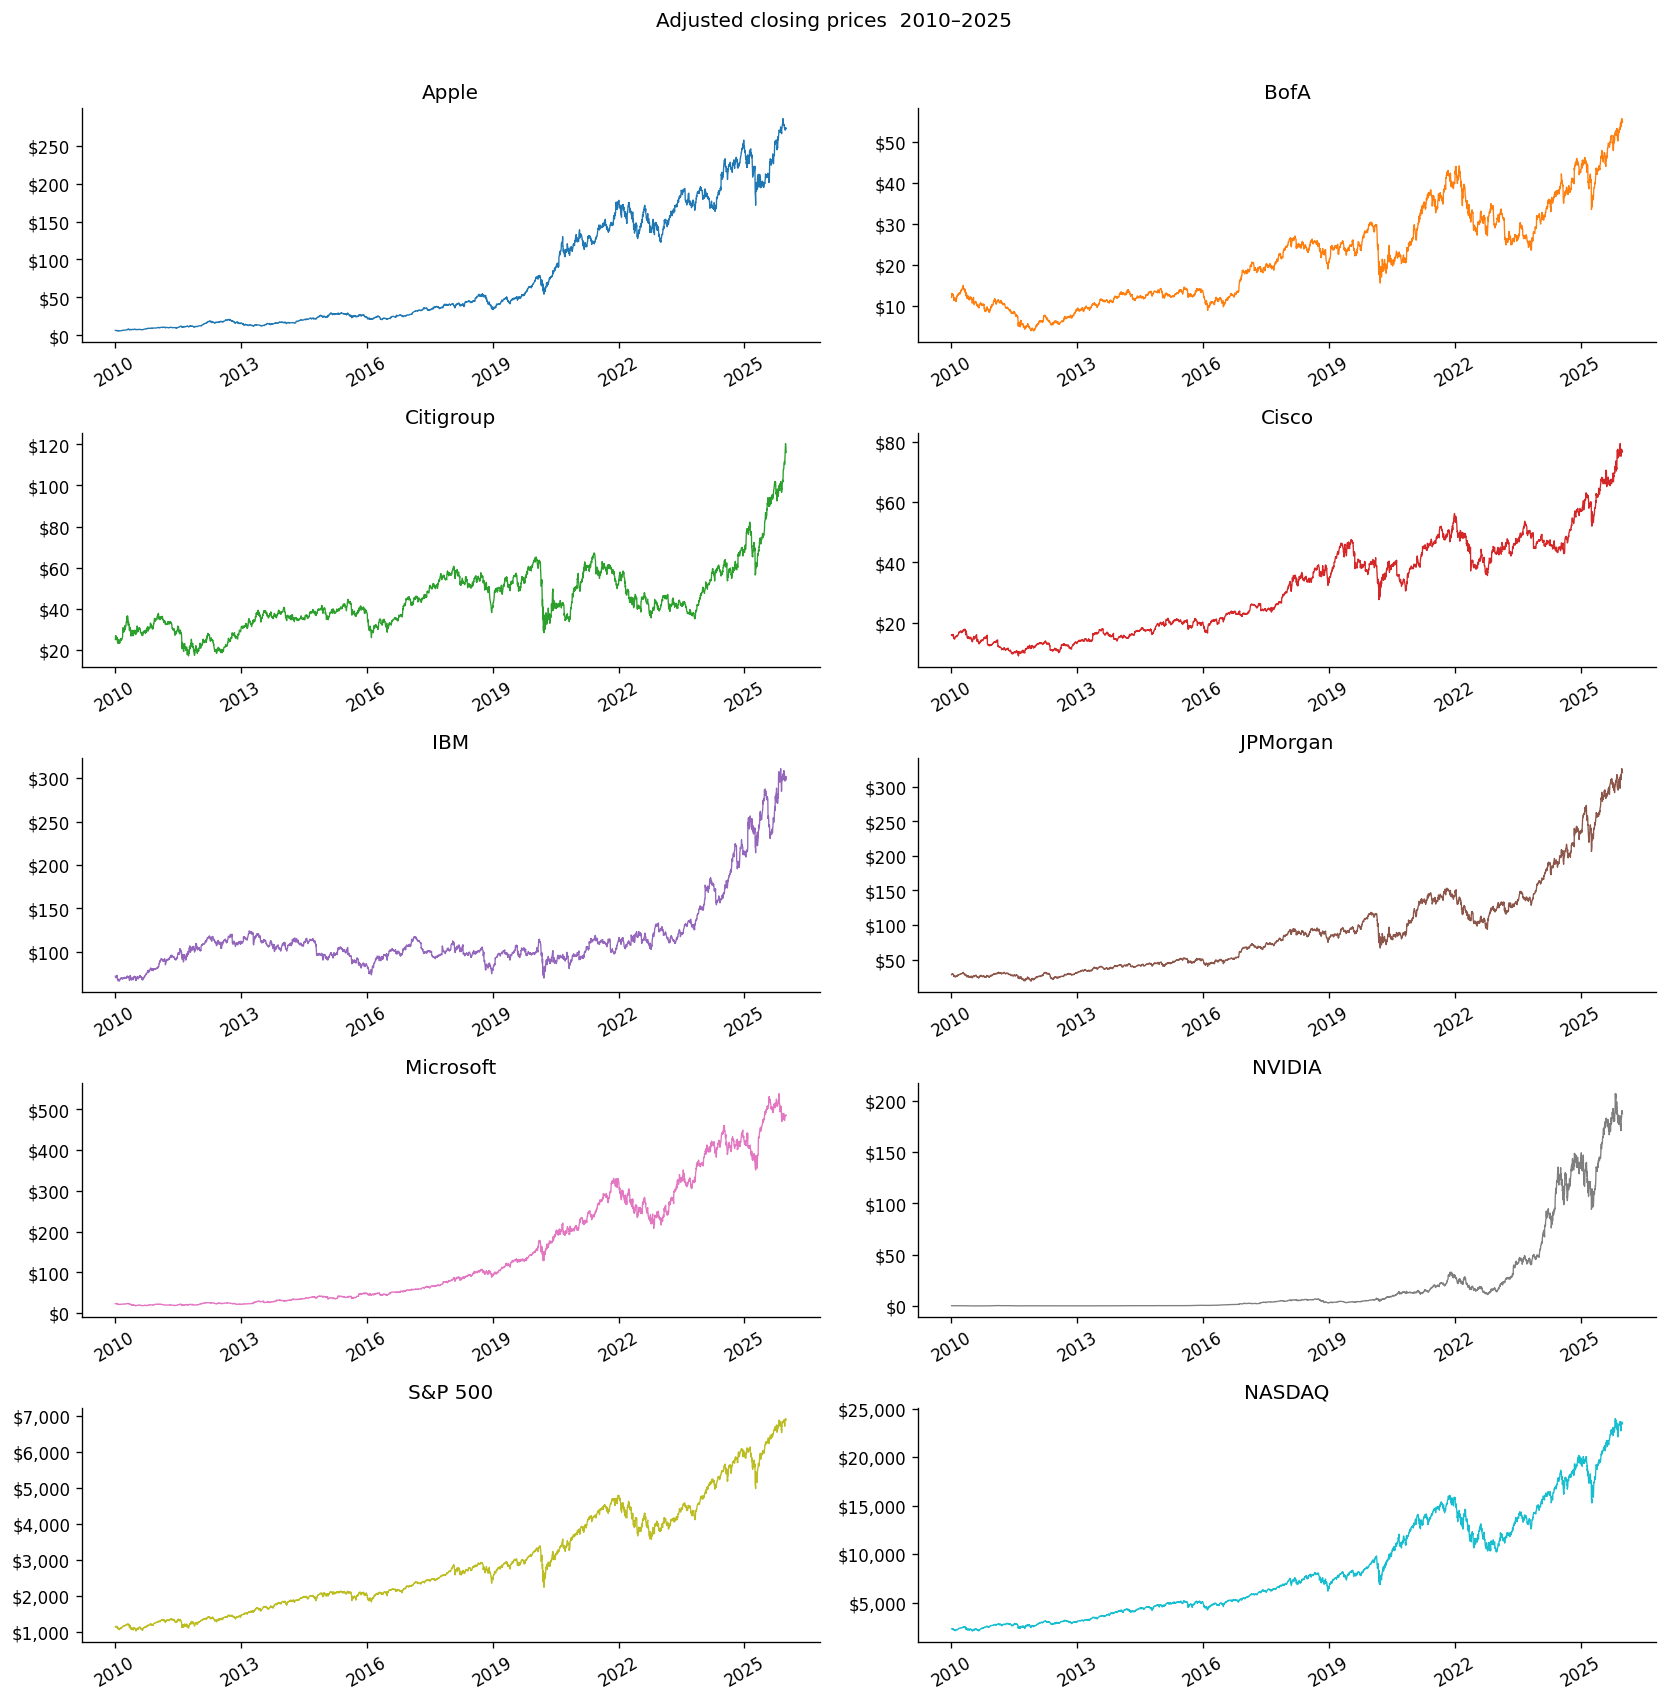

In [3]:
fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(14, N_ROWS * 2.8))
axes = axes.flatten()
for i, t in enumerate(prices.columns):
    axes[i].plot(prices[t], color=PALETTE[i], lw=0.8)
    axes[i].set_title(NAMES.get(t, t))
    axes[i].xaxis.set_major_locator(mdates.YearLocator(3))
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[i].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
    axes[i].tick_params(axis='x', rotation=30)
for j in range(len(TICKERS), len(axes)): axes[j].set_visible(False)
plt.suptitle('Adjusted closing prices  2010–2025', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'price_history.png', bbox_inches='tight')
plt.show()


## 3. Log Returns

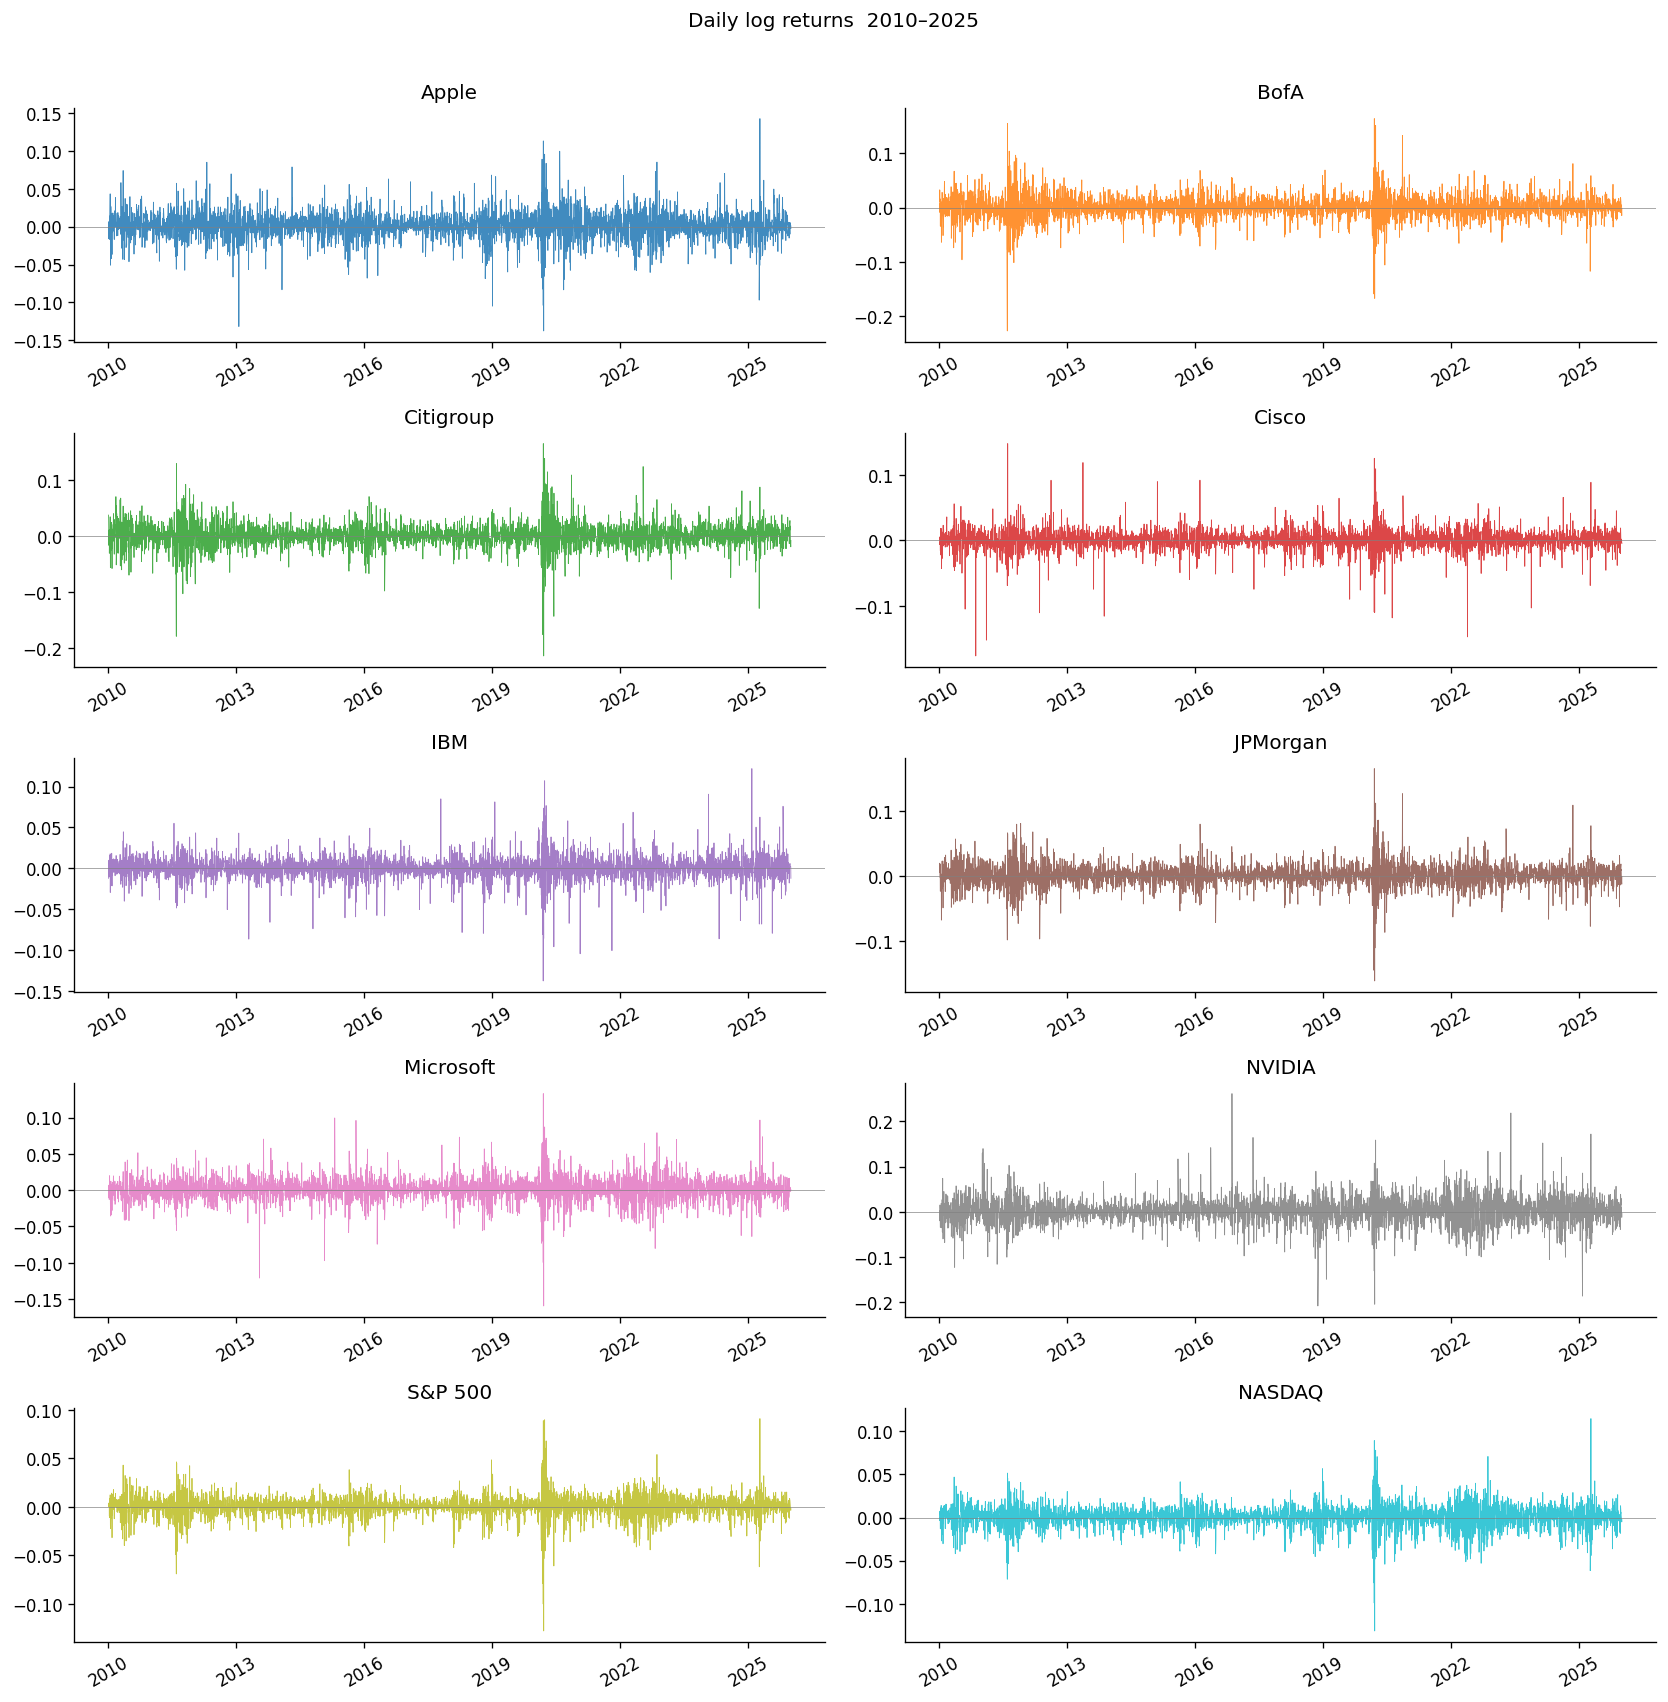

In [4]:
pct = prices.pct_change().dropna()

fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(14, N_ROWS * 2.8))
axes = axes.flatten()
for i, t in enumerate(ret.columns):
    axes[i].plot(ret[t], color=PALETTE[i], lw=0.5, alpha=0.85)
    axes[i].set_title(NAMES.get(t, t))
    axes[i].axhline(0, color='grey', lw=0.4)
    axes[i].xaxis.set_major_locator(mdates.YearLocator(3))
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[i].tick_params(axis='x', rotation=30)
for j in range(len(TICKERS), len(axes)): axes[j].set_visible(False)
plt.suptitle('Daily log returns  2010–2025', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'log_returns.png', bbox_inches='tight')
plt.show()


## 4. Descriptive Statistics

In [5]:
def desc_stats(df, td=252):
    rows = {}
    for c in df.columns:
        r = df[c].dropna()
        jb_stat, jb_p = jarque_bera(r)
        rows[NAMES.get(c, c)] = {
            'N':              len(r),
            'Mean (d)':       r.mean(),
            'Std (d)':        r.std(),
            'Min':            r.min(),
            'Max':            r.max(),
            'Skewness':       float(r.skew()),
            'Ex. Kurtosis':   float(r.kurtosis()),
            'Ann. Ret (%)':   r.mean() * td * 100,
            'Ann. Vol (%)':   r.std() * np.sqrt(td) * 100,
            'Sharpe':         (r.mean() * td) / (r.std() * np.sqrt(td)),
            'JB stat':        jb_stat,
            'JB p-val':       jb_p,
        }
    return pd.DataFrame(rows).T

desc = desc_stats(ret)
print(desc.to_string())


                    N  Mean (d)  Std (d)       Min      Max  Skewness  Ex. Kurtosis  Ann. Ret (%)  Ann. Vol (%)   Sharpe      JB stat  JB p-val
Apple     4022.000000  0.000933 0.017741 -0.137708 0.142617 -0.150380      6.148600     23.499525     28.162435 0.834428  6331.875720  0.000000
BofA      4022.000000  0.000376 0.020958 -0.227129 0.163786 -0.318631     10.189798      9.482919     33.269563 0.285033 17420.205798  0.000000
Citigroup 4022.000000  0.000382 0.021347 -0.214414 0.165381 -0.495355     10.470159      9.623924     33.886942 0.284001 18484.696007  0.000000
Cisco     4022.000000  0.000391 0.016293 -0.176865 0.147993 -0.843276     16.515216      9.853878     25.864674 0.380978 46063.296935  0.000000
IBM       4022.000000  0.000353 0.014379 -0.137548 0.121901 -0.502706     10.690307      8.908079     22.825764 0.390264 19268.236304  0.000000
JPMorgan  4022.000000  0.000603 0.017372 -0.162105 0.165620 -0.111683      9.549255     15.207844     27.577206 0.551464 15247.263786  0

## 5. Distributions

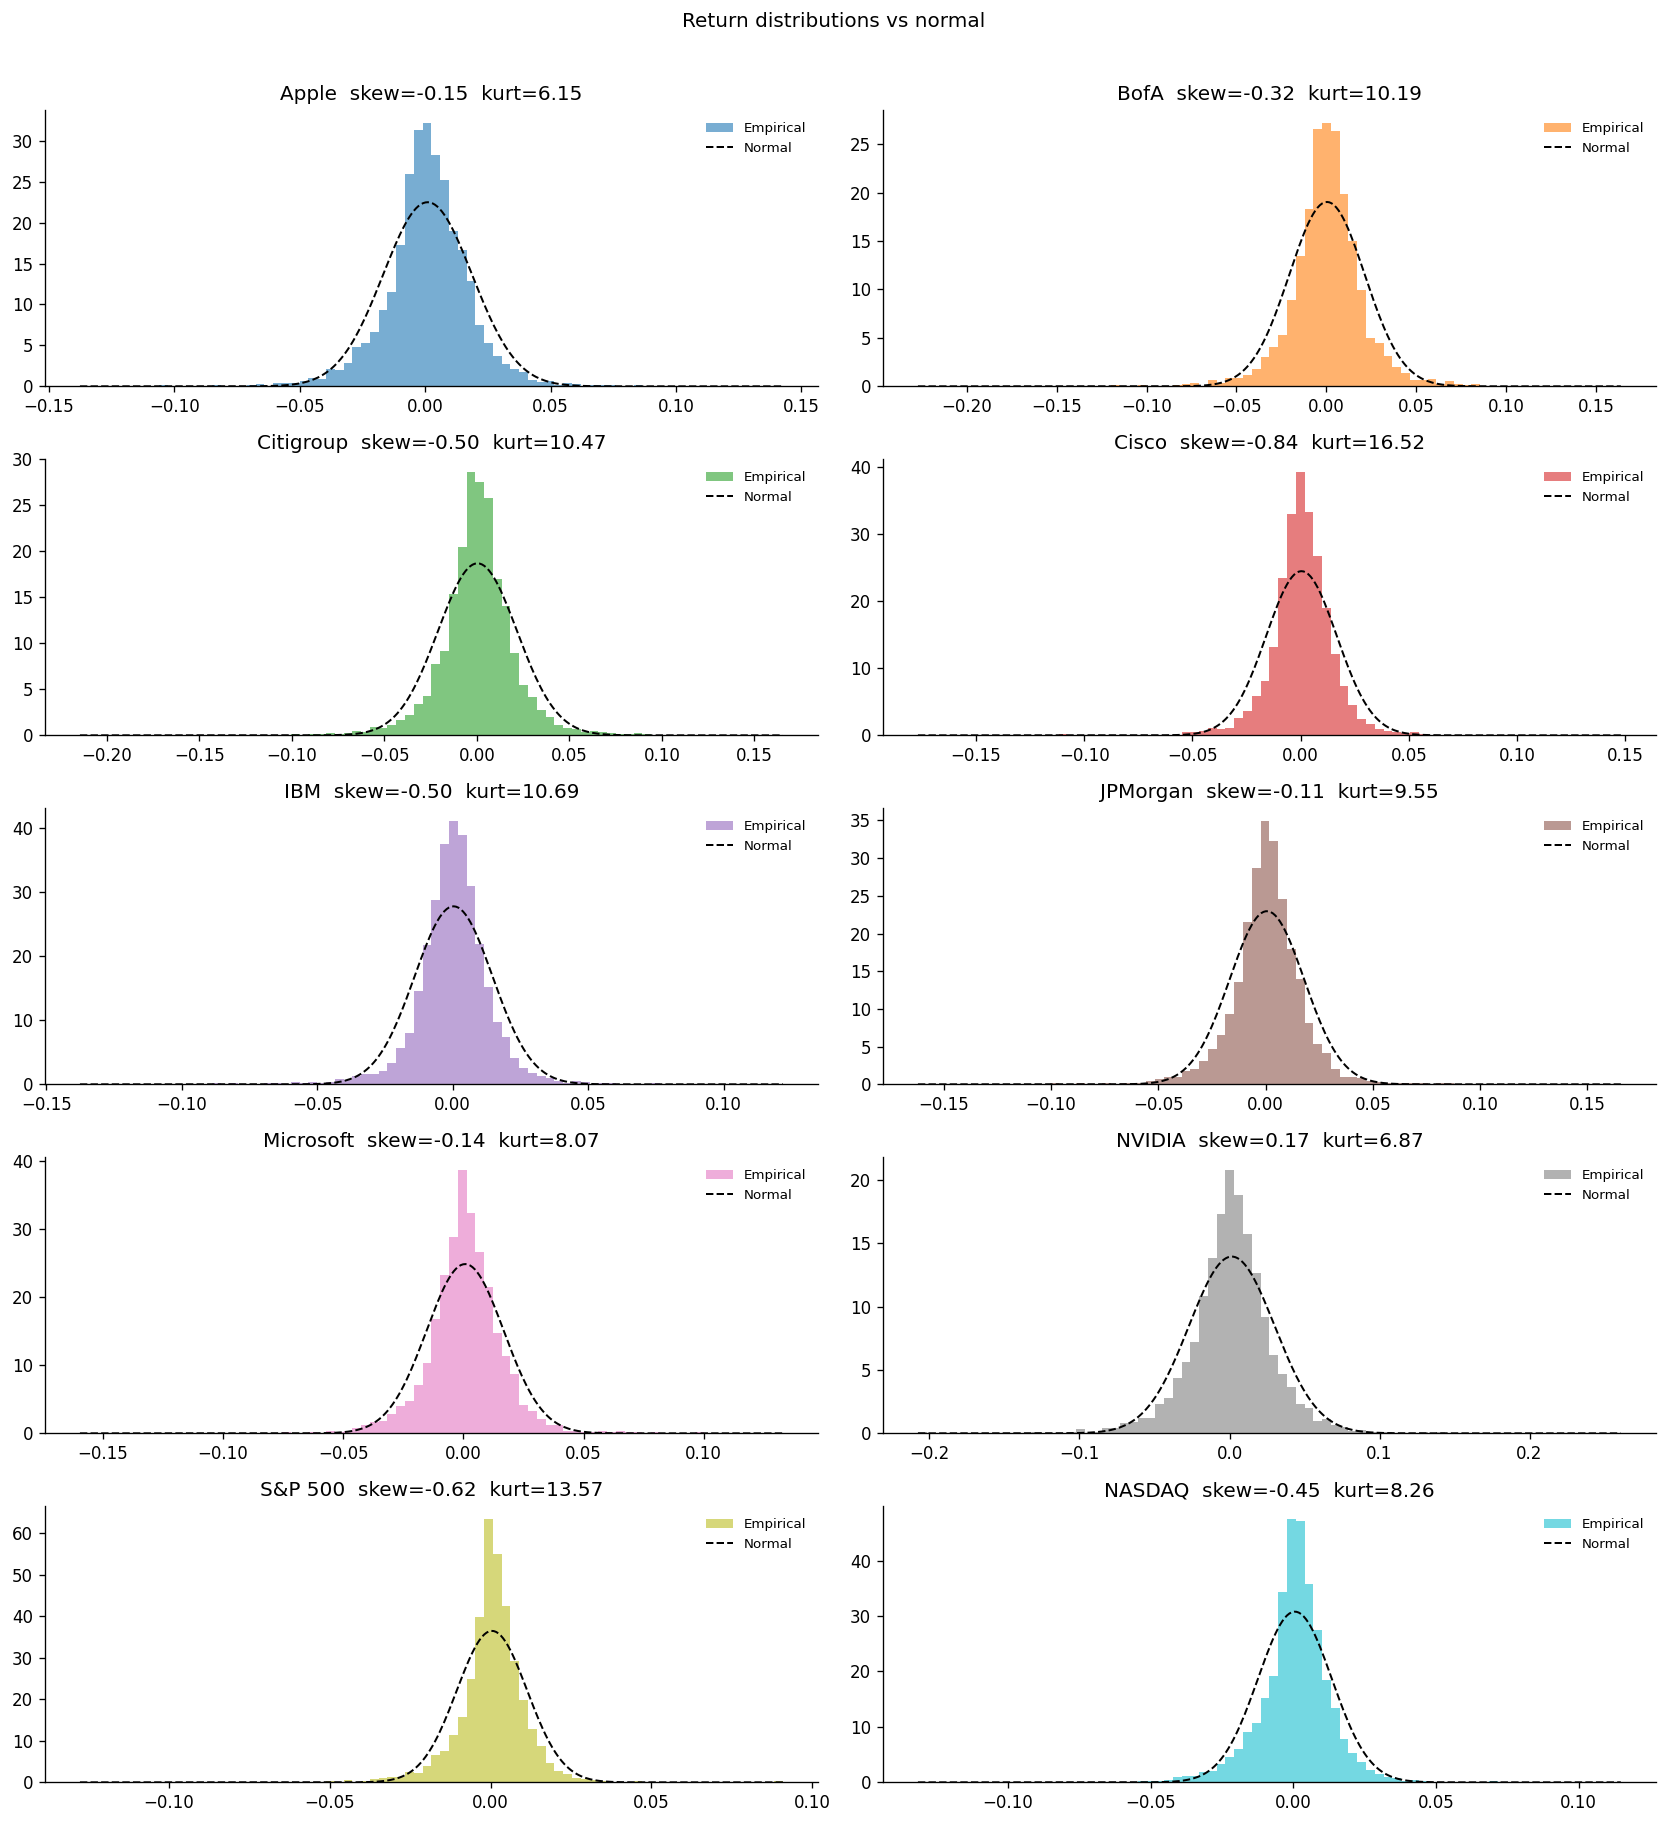

In [6]:
fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(14, N_ROWS * 3))
axes = axes.flatten()
for i, t in enumerate(ret.columns):
    r  = ret[t].dropna()
    x  = np.linspace(r.min(), r.max(), 300)
    axes[i].hist(r, bins=80, density=True, color=PALETTE[i], alpha=0.6, label='Empirical')
    axes[i].plot(x, norm.pdf(x, r.mean(), r.std()), 'k--', lw=1.2, label='Normal')
    axes[i].set_title(f"{NAMES.get(t,t)}  skew={r.skew():.2f}  kurt={r.kurtosis():.2f}")
    axes[i].legend(frameon=False, fontsize=8)
for j in range(len(TICKERS), len(axes)): axes[j].set_visible(False)
plt.suptitle('Return distributions vs normal', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'return_distributions.png', bbox_inches='tight')
plt.show()


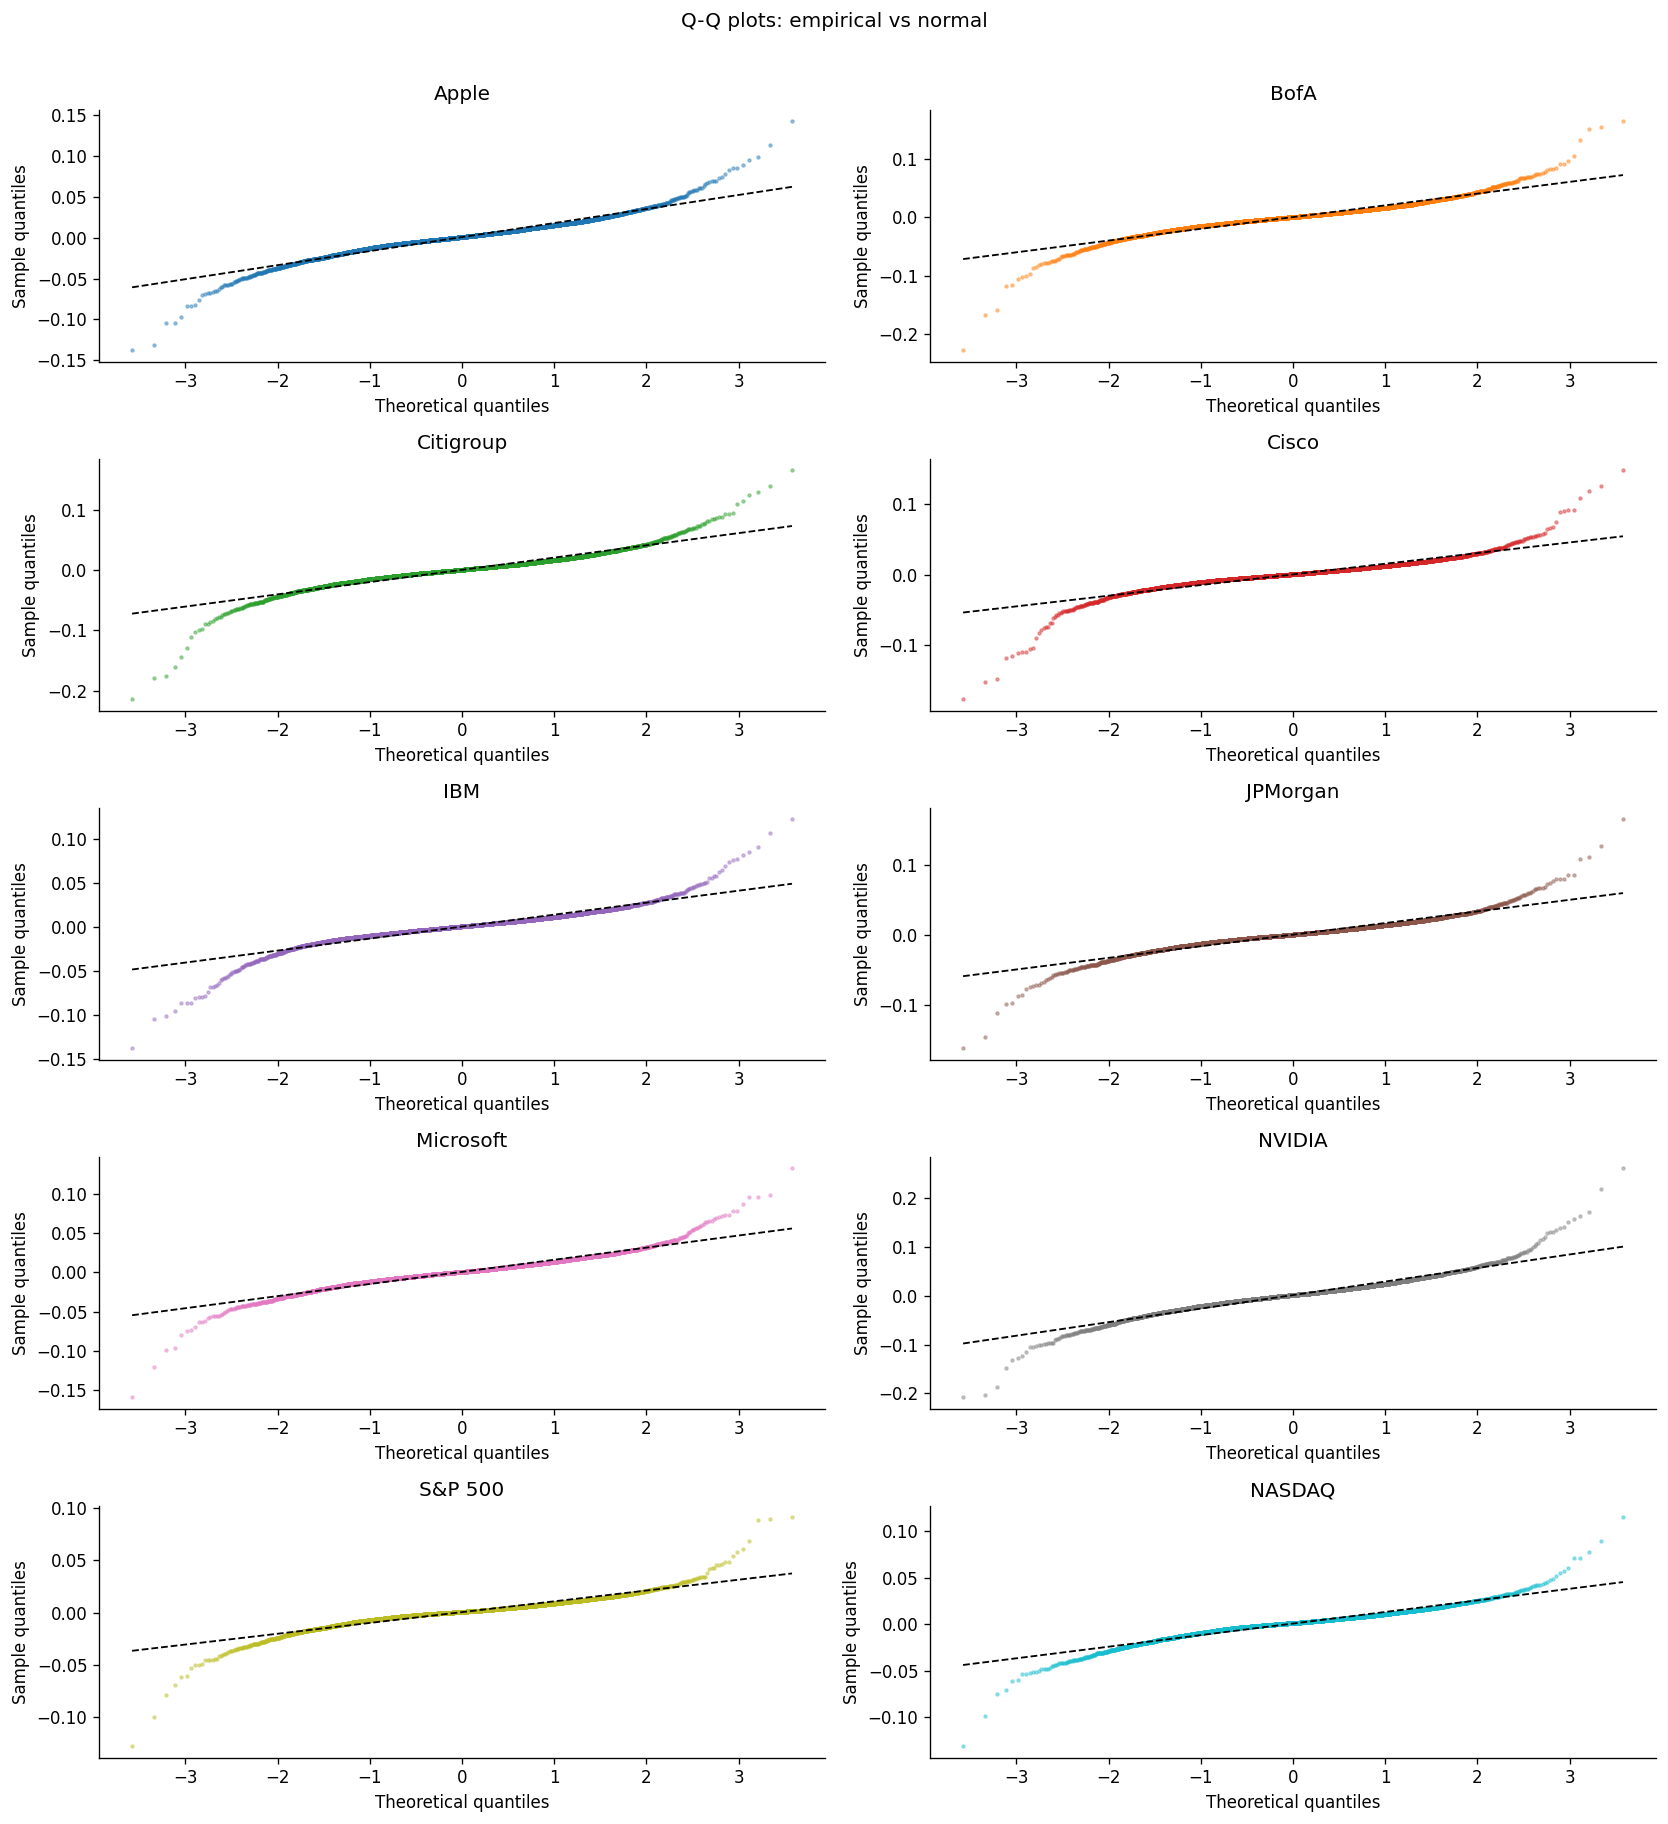

In [7]:
fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(14, N_ROWS * 3))
axes = axes.flatten()
for i, t in enumerate(ret.columns):
    r = ret[t].dropna()
    (osm, osr), (slope, intercept, _) = stats.probplot(r, dist='norm')
    axes[i].scatter(osm, osr, color=PALETTE[i], s=3, alpha=0.4)
    axes[i].plot(osm, slope * np.array(osm) + intercept, 'k--', lw=1.1)
    axes[i].set_title(NAMES.get(t, t))
    axes[i].set_xlabel('Theoretical quantiles')
    axes[i].set_ylabel('Sample quantiles')
for j in range(len(TICKERS), len(axes)): axes[j].set_visible(False)
plt.suptitle('Q-Q plots: empirical vs normal', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'qq_plots.png', bbox_inches='tight')
plt.show()


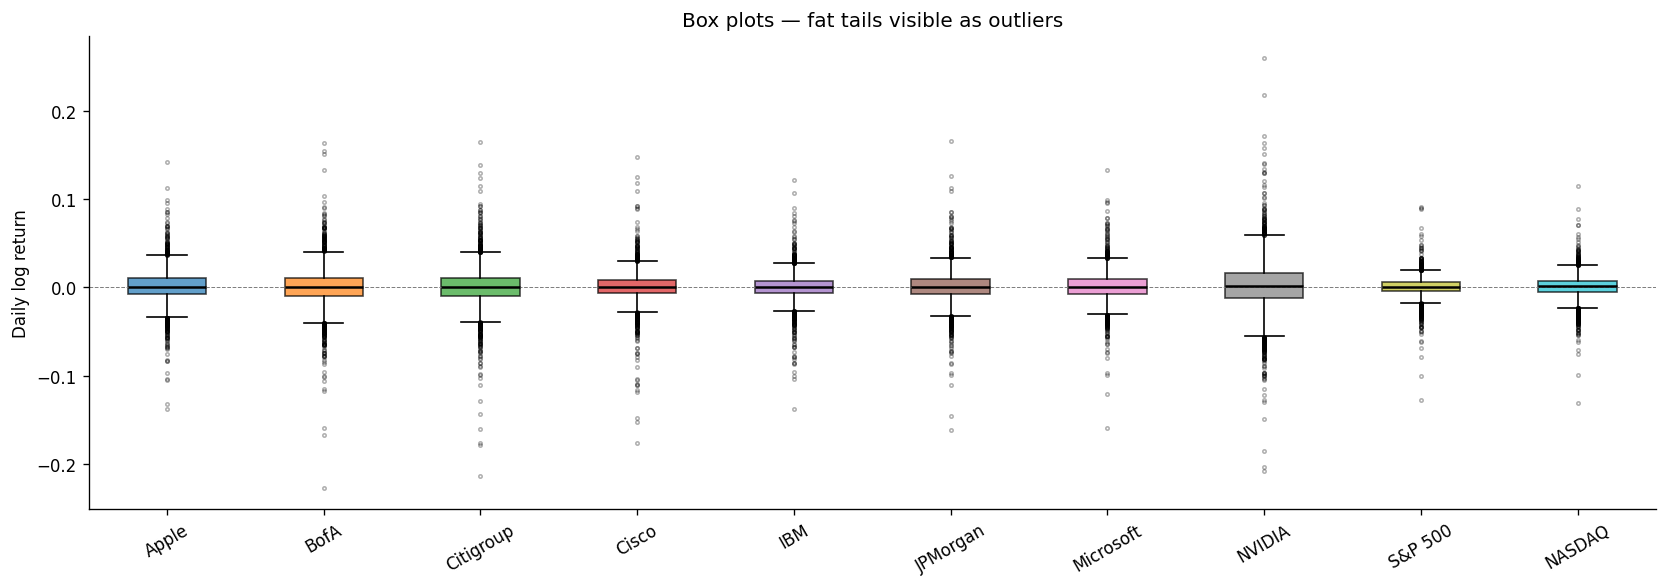

In [8]:
fig, ax = plt.subplots(figsize=(14, 5))
bp = ax.boxplot(
    [ret[t].dropna().values for t in ret.columns],
    labels=[NAMES.get(t, t) for t in ret.columns],
    patch_artist=True,
    medianprops=dict(color='black', lw=1.5),
    flierprops=dict(marker='o', ms=2, linestyle='none', alpha=0.3),
)
for patch, c in zip(bp['boxes'], PALETTE): patch.set_facecolor(c); patch.set_alpha(0.7)
ax.axhline(0, color='grey', lw=0.6, ls='--')
ax.set_ylabel('Daily log return')
ax.set_title('Box plots — fat tails visible as outliers')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'boxplots.png', bbox_inches='tight')
plt.show()


## 6. Normality Tests (Jarque-Bera)

In [9]:
jb_rows = []
for t in ret.columns:
    r = ret[t].dropna()
    stat, p = jarque_bera(r)
    jb_rows.append({
        'Asset':        NAMES.get(t, t),
        'JB stat':      round(stat, 2),
        'p-value':      p,
        'Skewness':     round(float(r.skew()), 4),
        'Ex. Kurtosis': round(float(r.kurtosis()), 4),
        'H0 rejected':  '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'No')),
    })
jb_df = pd.DataFrame(jb_rows).set_index('Asset')
print(jb_df.to_string())
print("\n*** p<0.001  ** p<0.01  * p<0.05 — all series reject normality as expected")


               JB stat  p-value  Skewness  Ex. Kurtosis H0 rejected
Asset                                                              
Apple      6331.880000 0.000000 -0.150400      6.148600         ***
BofA      17420.210000 0.000000 -0.318600     10.189800         ***
Citigroup 18484.700000 0.000000 -0.495400     10.470200         ***
Cisco     46063.300000 0.000000 -0.843300     16.515200         ***
IBM       19268.240000 0.000000 -0.502700     10.690300         ***
JPMorgan  15247.260000 0.000000 -0.111700      9.549300         ***
Microsoft 10894.400000 0.000000 -0.143400      8.069200         ***
NVIDIA     7909.660000 0.000000  0.172000      6.871500         ***
S&P 500   31048.000000 0.000000 -0.615200     13.574000         ***
NASDAQ    11537.000000 0.000000 -0.449100      8.260200         ***

*** p<0.001  ** p<0.01  * p<0.05 — all series reject normality as expected


## 7. Stylised Facts

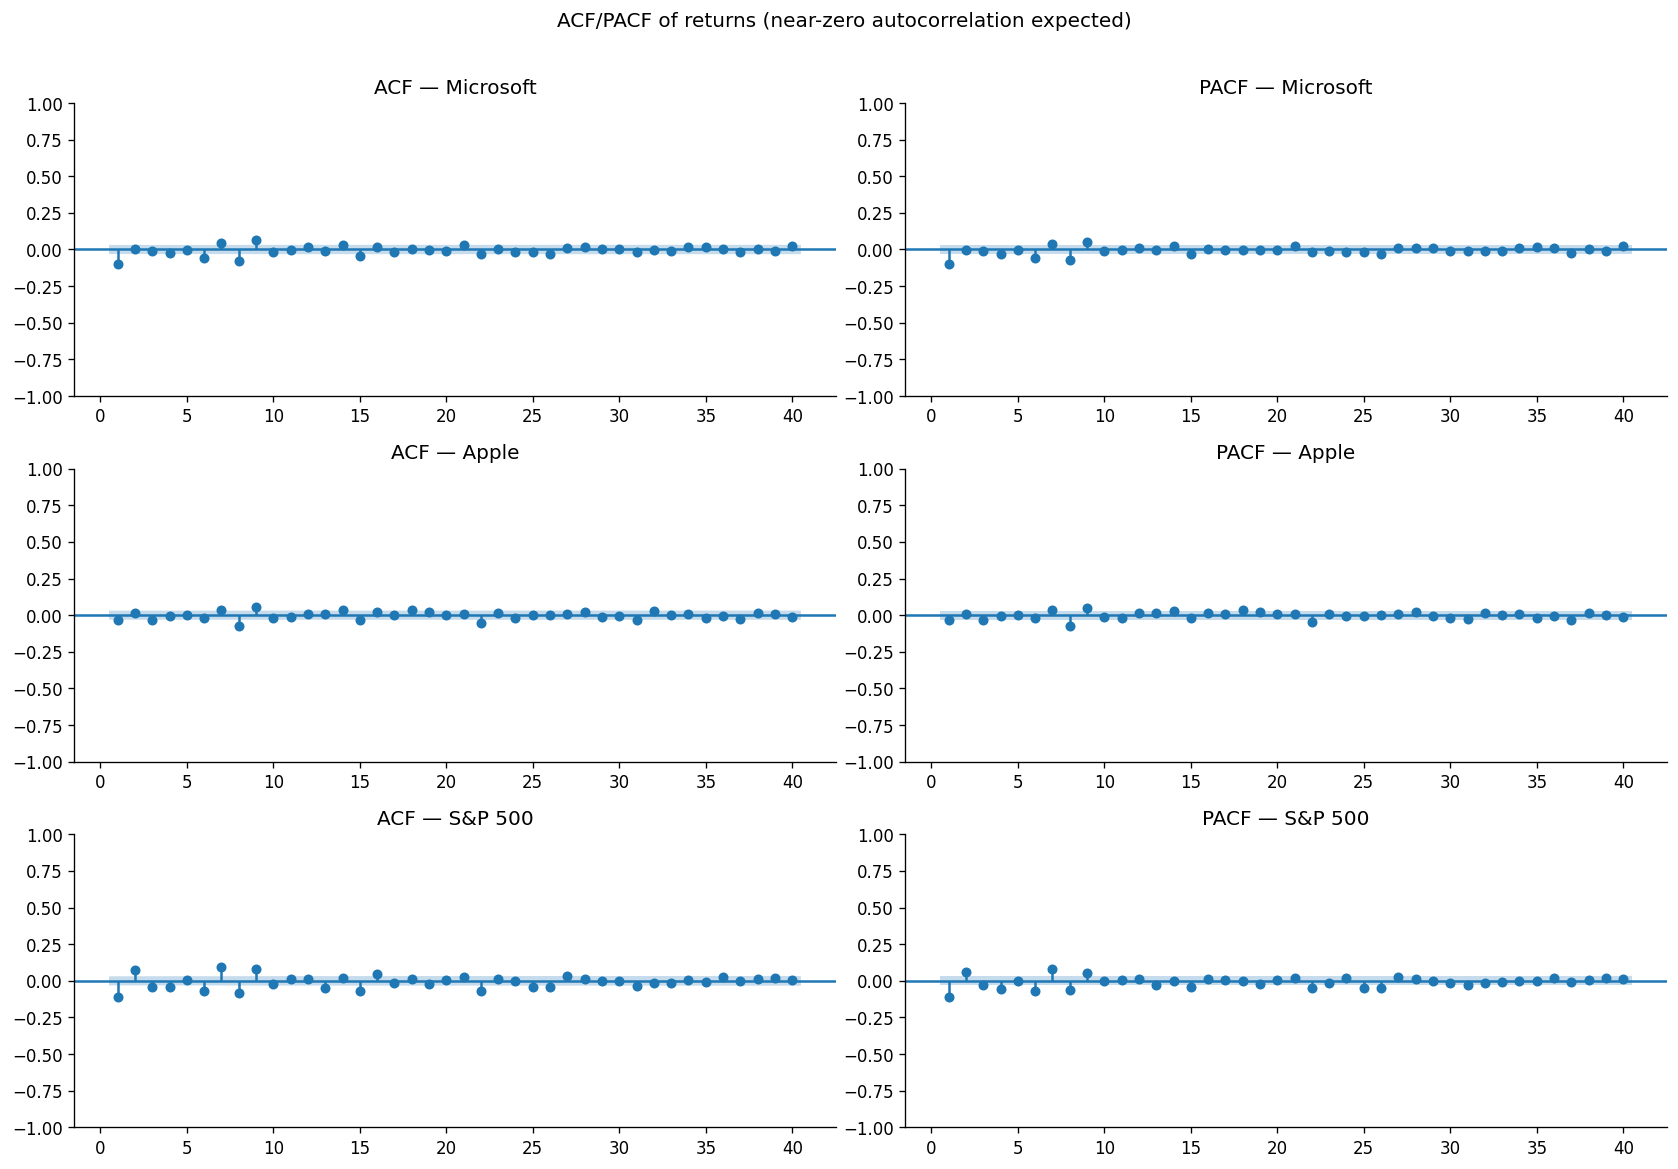

In [10]:
# ACF/PACF of returns — should show near-zero autocorrelation
focus = ['MSFT', 'AAPL', '^GSPC']
fig, axes = plt.subplots(len(focus), 2, figsize=(14, len(focus) * 3.2))
for i, t in enumerate(focus):
    r = ret[t].dropna()
    plot_acf(r,  lags=40, ax=axes[i, 0], title=f'ACF — {NAMES[t]}',  zero=False)
    plot_pacf(r, lags=40, ax=axes[i, 1], title=f'PACF — {NAMES[t]}', zero=False)
plt.suptitle('ACF/PACF of returns (near-zero autocorrelation expected)', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'acf_returns.png', bbox_inches='tight')
plt.show()


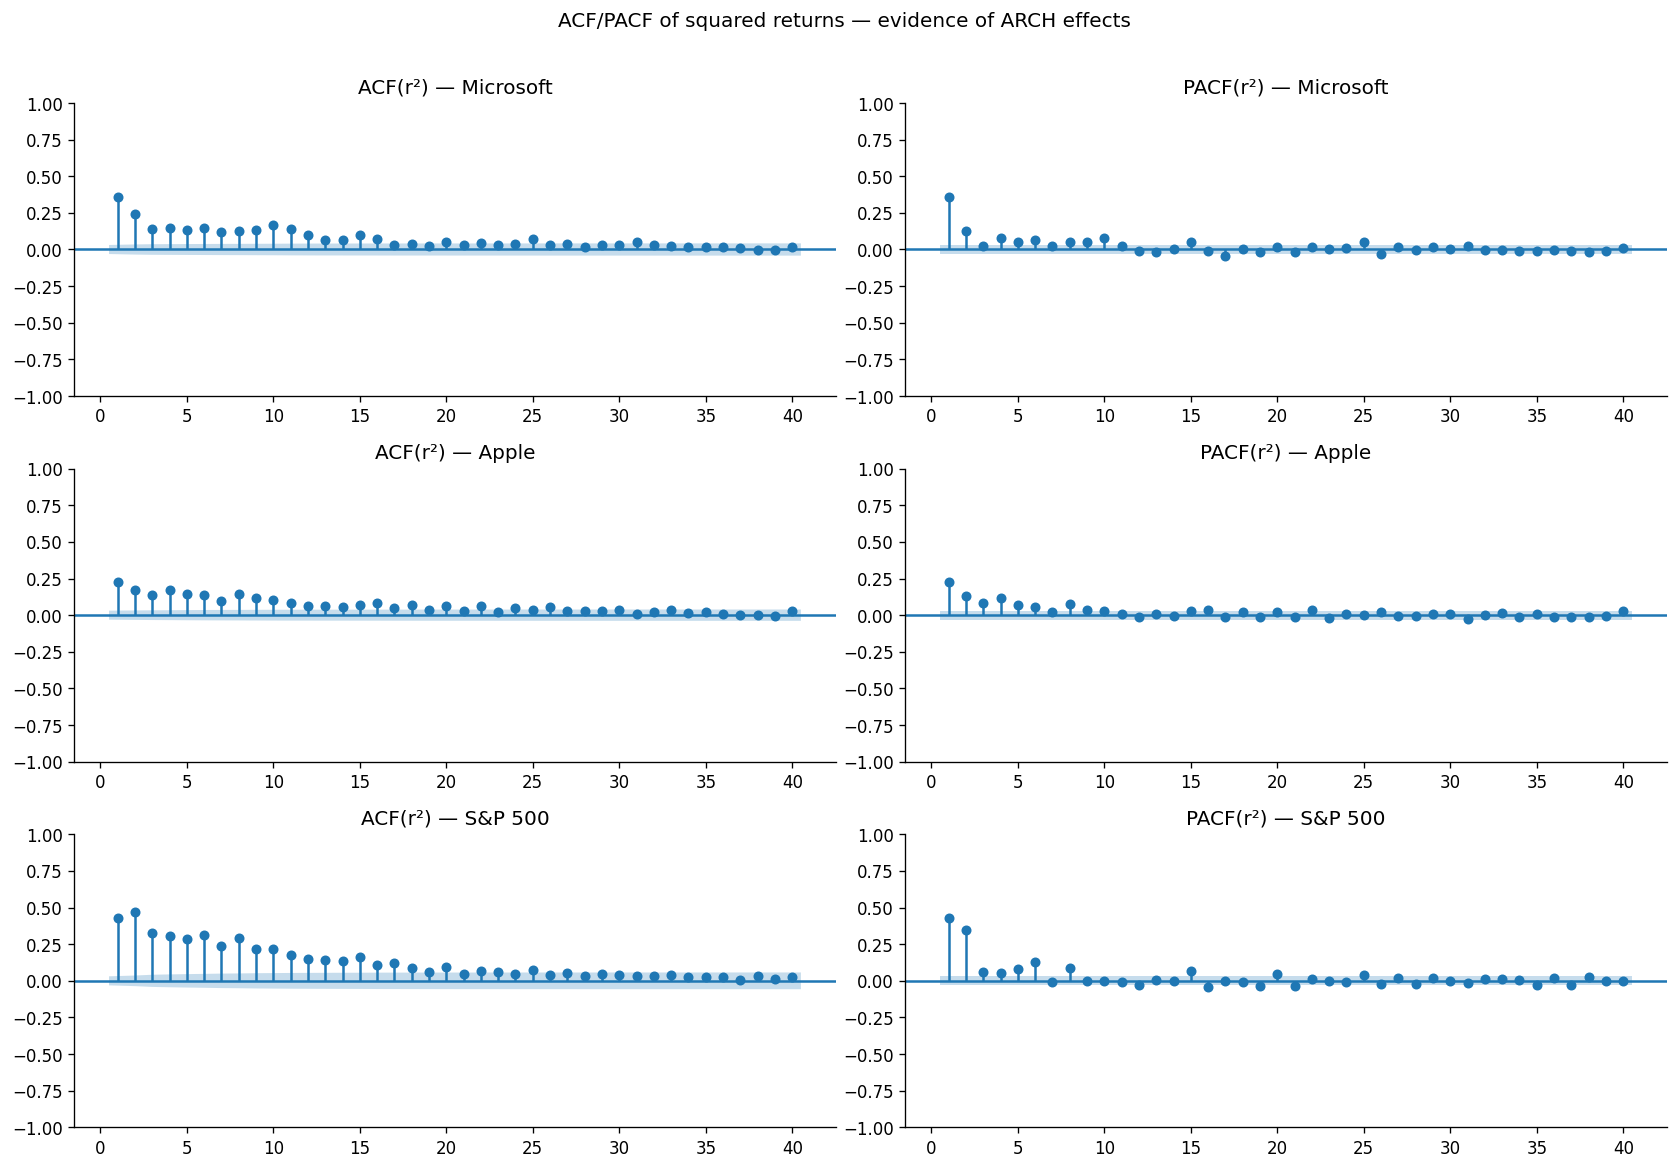

In [11]:
# ACF/PACF of squared returns — persistent autocorrelation = volatility clustering
fig, axes = plt.subplots(len(focus), 2, figsize=(14, len(focus) * 3.2))
for i, t in enumerate(focus):
    r2 = ret[t].dropna() ** 2
    plot_acf(r2,  lags=40, ax=axes[i, 0], title=f'ACF(r²) — {NAMES[t]}',  zero=False)
    plot_pacf(r2, lags=40, ax=axes[i, 1], title=f'PACF(r²) — {NAMES[t]}', zero=False)
plt.suptitle('ACF/PACF of squared returns — evidence of ARCH effects', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'acf_squared.png', bbox_inches='tight')
plt.show()


## 8. Correlation

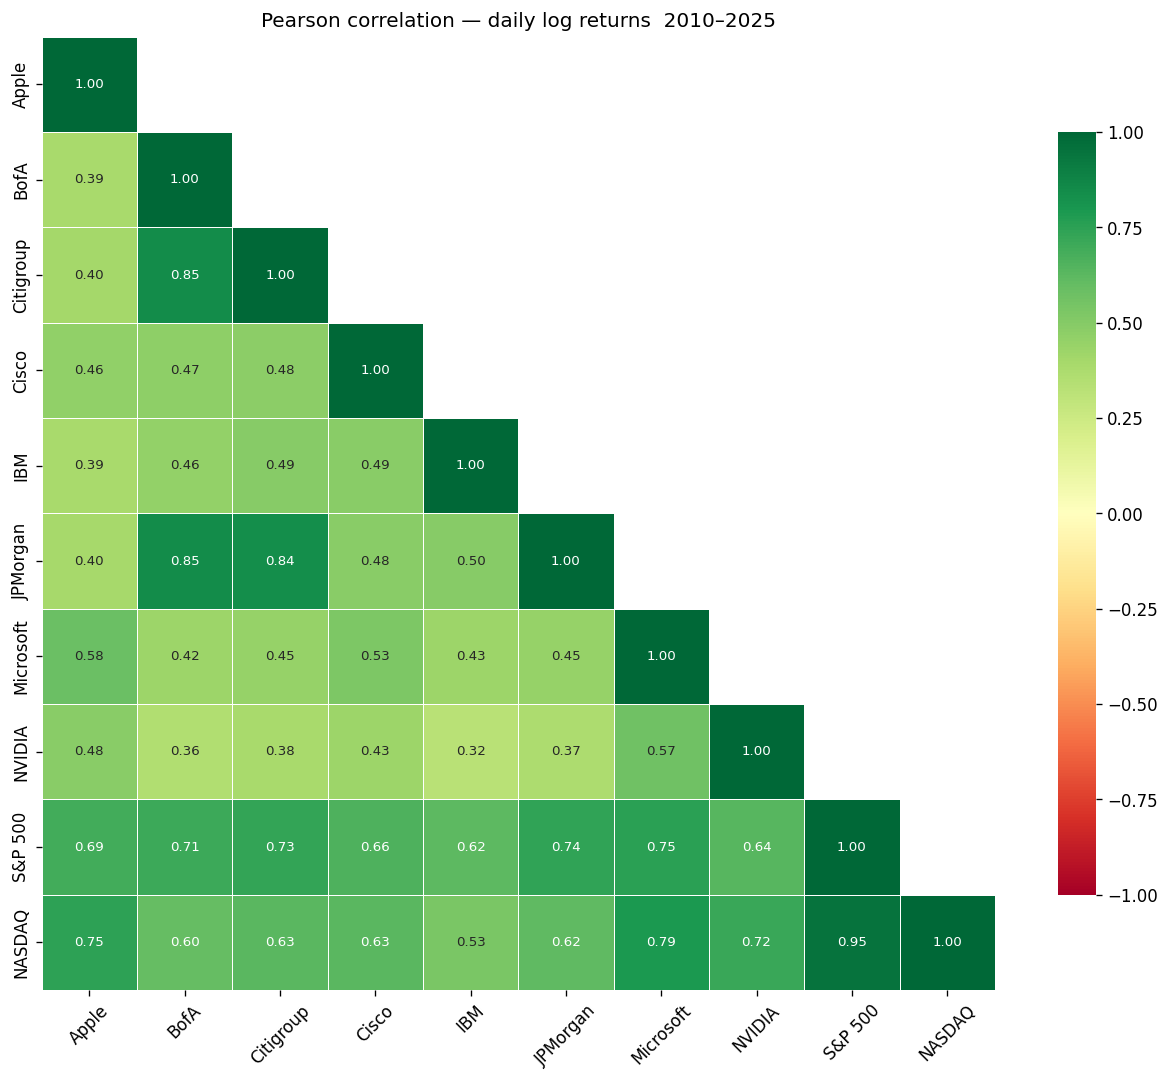

In [12]:
corr = ret.rename(columns=NAMES).corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.3,
            cbar_kws={'shrink': 0.8}, annot_kws={'size': 8}, ax=ax)
ax.set_title('Pearson correlation — daily log returns  2010–2025')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'correlation_heatmap.png', bbox_inches='tight')
plt.show()


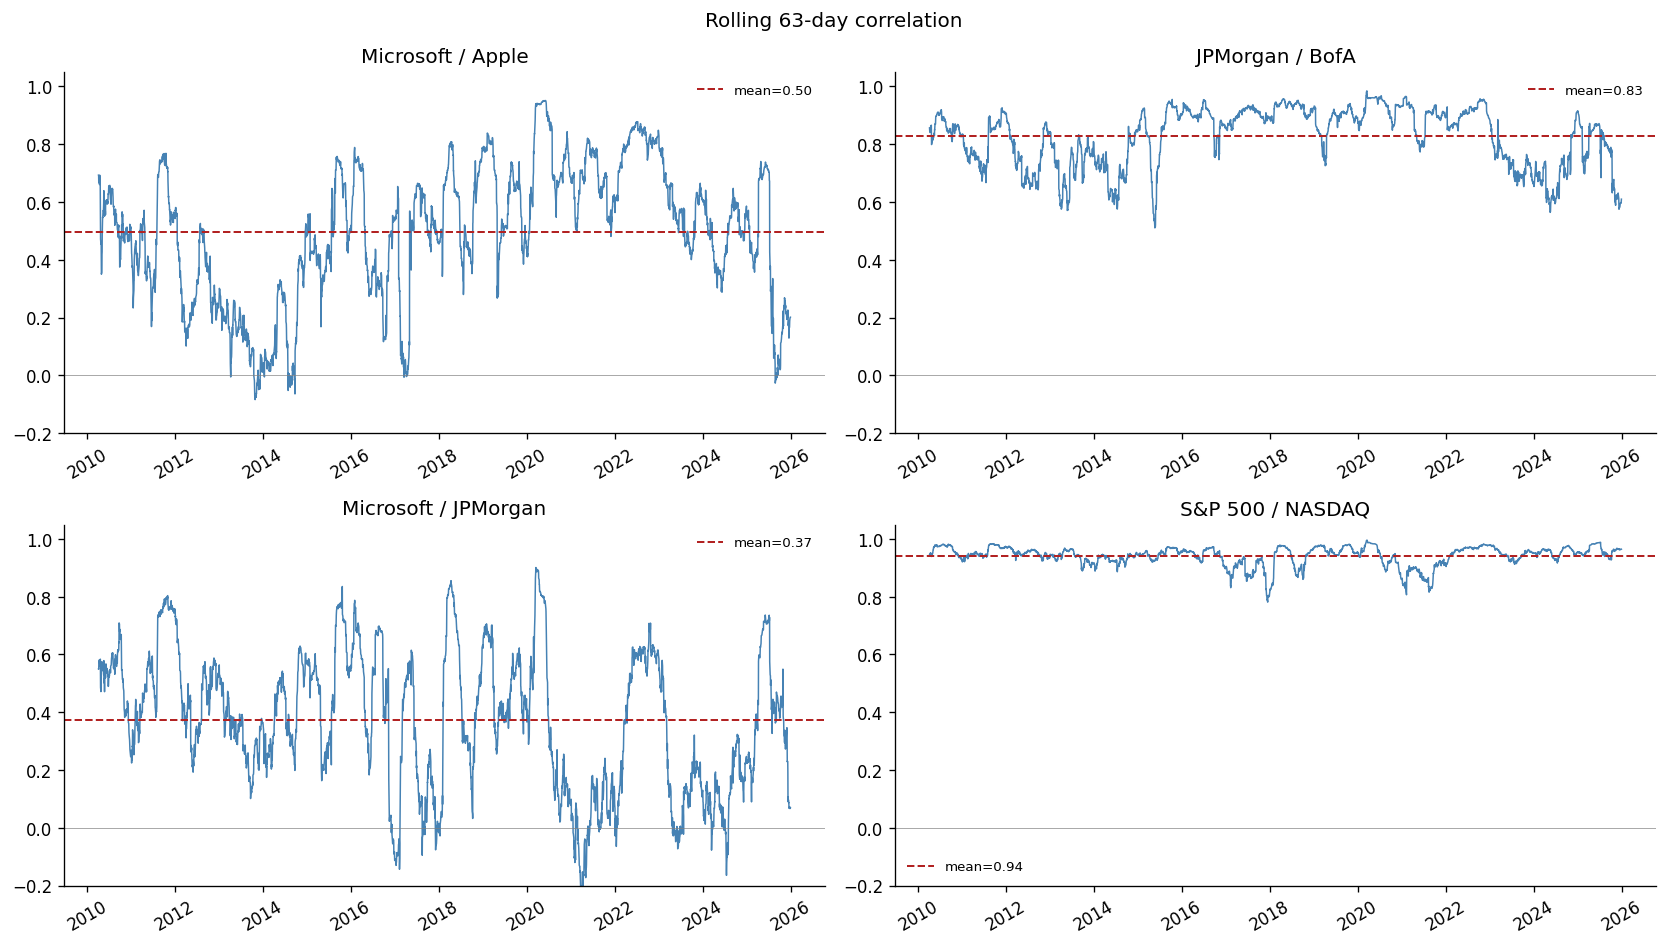

In [13]:
pairs = [('MSFT', 'AAPL'), ('JPM', 'BAC'), ('MSFT', 'JPM'), ('^GSPC', '^IXIC')]
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, (t1, t2) in zip(axes, pairs):
    rc = ret[t1].rolling(63).corr(ret[t2])
    ax.plot(rc, lw=0.9, color='steelblue')
    ax.axhline(rc.mean(), color='firebrick', lw=1.2, ls='--', label=f'mean={rc.mean():.2f}')
    ax.set_title(f'{NAMES[t1]} / {NAMES[t2]}')
    ax.set_ylim(-0.2, 1.05)
    ax.axhline(0, color='grey', lw=0.4)
    ax.legend(frameon=False, fontsize=8)
    ax.xaxis.set_major_locator(mdates.YearLocator(2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Rolling 63-day correlation')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'rolling_correlation.png', bbox_inches='tight')
plt.show()


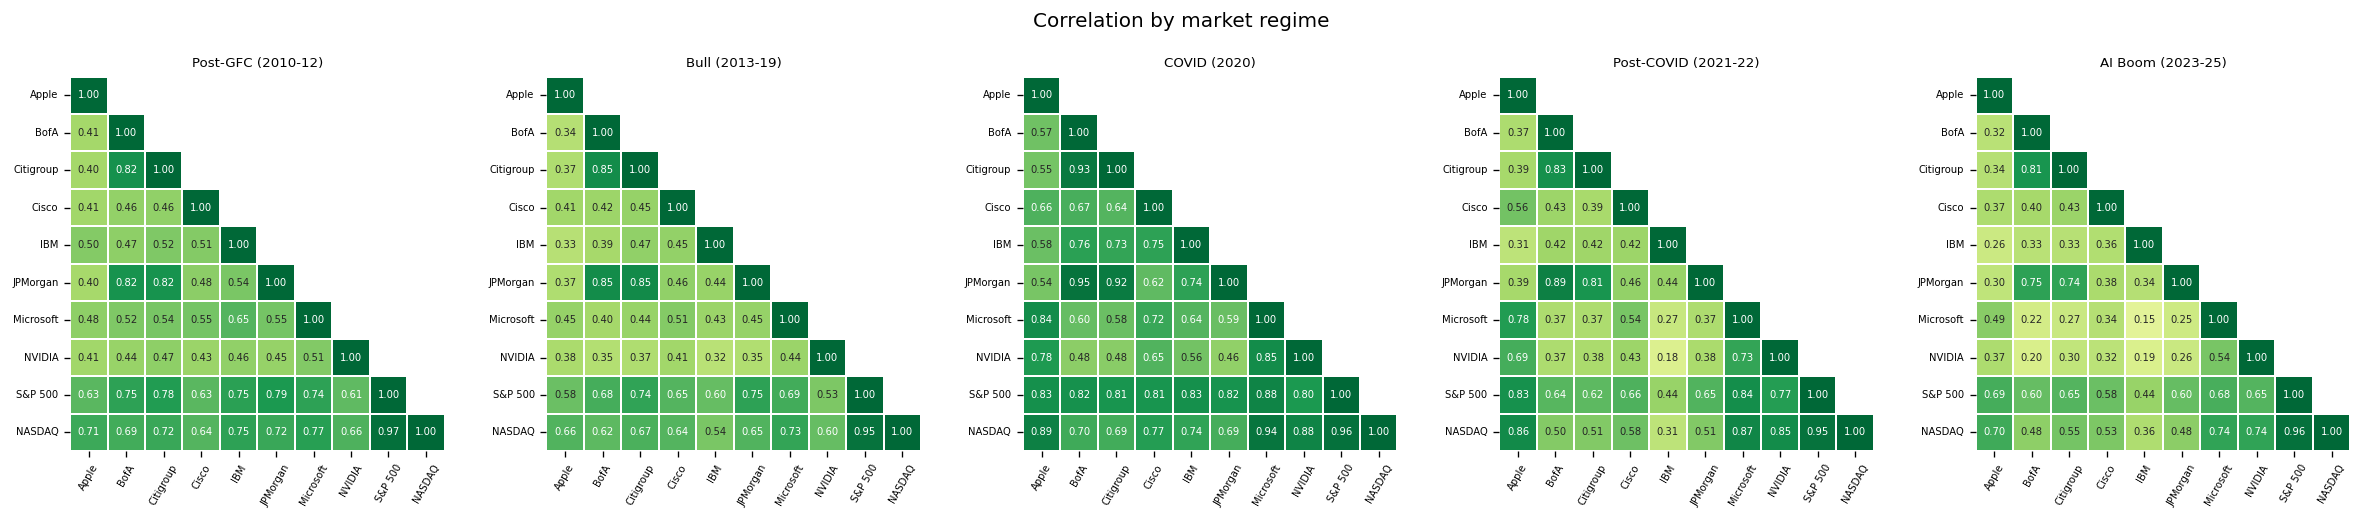

In [14]:
REGIMES = {
    'Post-GFC (2010-12)':   ('2010-01-01', '2012-12-31'),
    'Bull (2013-19)':        ('2013-01-01', '2019-12-31'),
    'COVID (2020)':          ('2020-01-01', '2020-12-31'),
    'Post-COVID (2021-22)':  ('2021-01-01', '2022-12-31'),
    'AI Boom (2023-25)':     ('2023-01-01', '2025-12-31'),
}

fig, axes = plt.subplots(1, len(REGIMES), figsize=(20, 4))
for ax, (regime, (s, e)) in zip(axes, REGIMES.items()):
    sub = ret.loc[s:e].rename(columns=NAMES)
    if len(sub) < 5: ax.set_visible(False); continue
    c = sub.corr()
    sns.heatmap(c, mask=np.triu(np.ones_like(c, dtype=bool), k=1),
                annot=True, fmt='.2f', cmap='RdYlGn', center=0,
                vmin=-1, vmax=1, square=True, linewidths=0.2,
                cbar=False, annot_kws={'size': 6}, ax=ax)
    ax.set_title(regime, fontsize=8)
    ax.tick_params(labelsize=6, axis='x', rotation=60)
    ax.tick_params(labelsize=6, axis='y', rotation=0)
plt.suptitle('Correlation by market regime', y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'regime_correlation.png', bbox_inches='tight')
plt.show()


## 9. Volatility

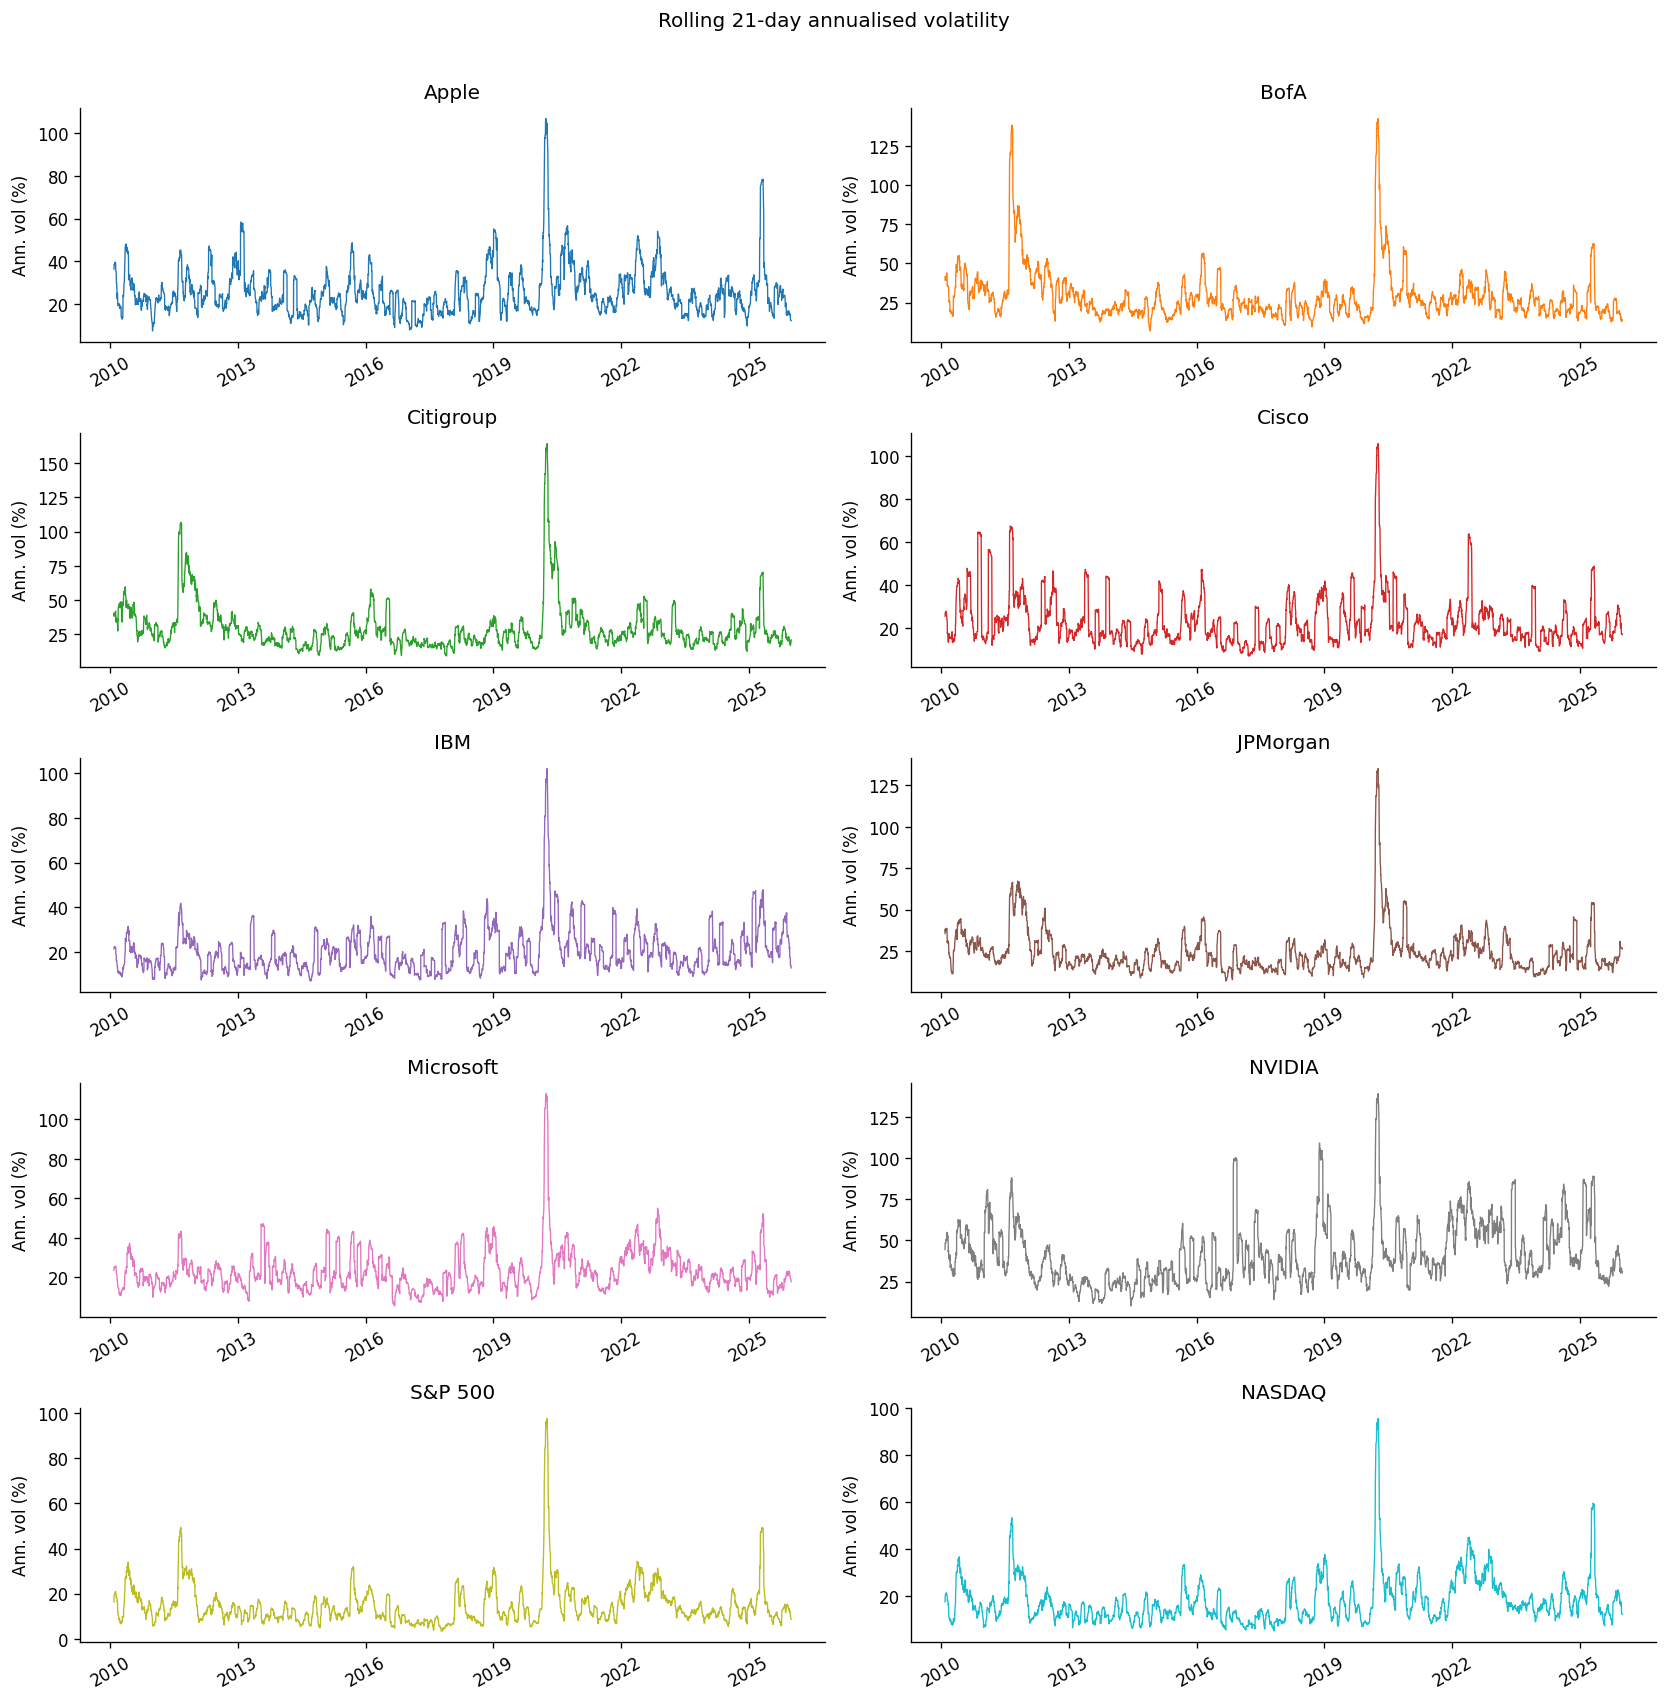

In [15]:
roll_vol = ret.rolling(21).std() * np.sqrt(252)

fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(14, N_ROWS * 2.8))
axes = axes.flatten()
for i, t in enumerate(roll_vol.columns):
    axes[i].plot(roll_vol[t] * 100, color=PALETTE[i], lw=0.8)
    axes[i].set_title(NAMES.get(t, t))
    axes[i].set_ylabel('Ann. vol (%)')
    axes[i].xaxis.set_major_locator(mdates.YearLocator(3))
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[i].tick_params(axis='x', rotation=30)
for j in range(len(TICKERS), len(axes)): axes[j].set_visible(False)
plt.suptitle('Rolling 21-day annualised volatility', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'rolling_volatility.png', bbox_inches='tight')
plt.show()


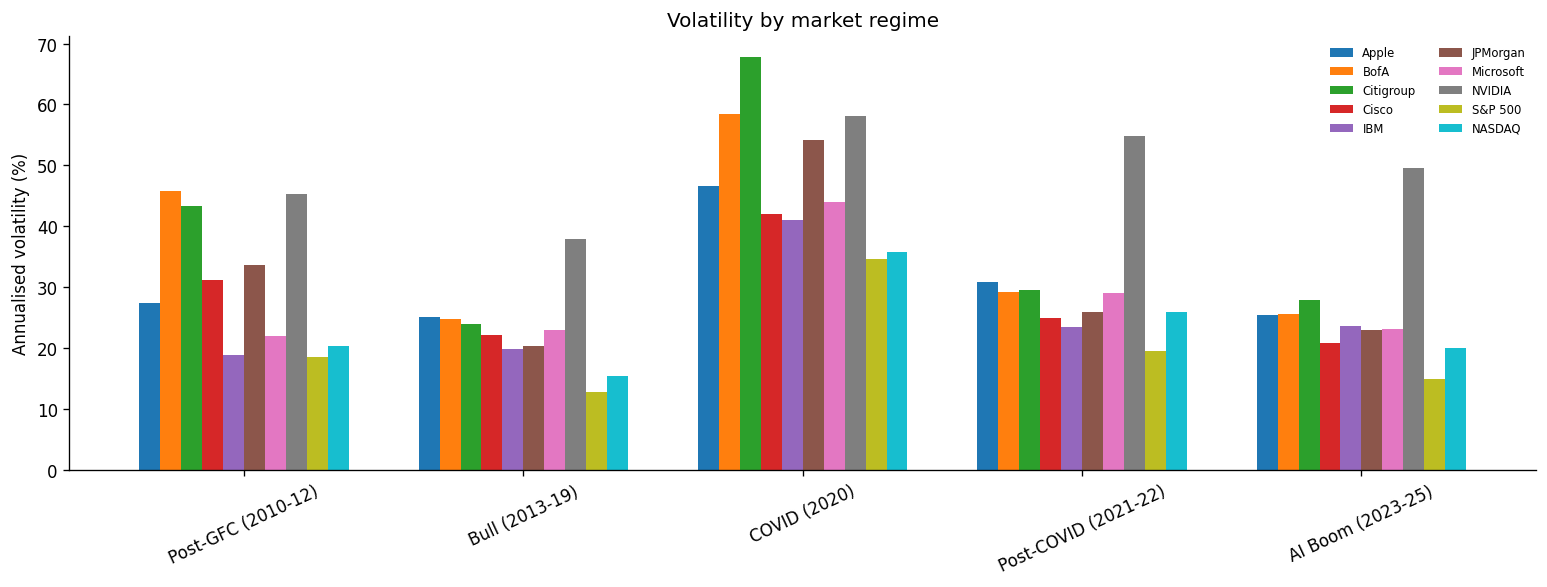

           Post-GFC (2010-12)  Bull (2013-19)  COVID (2020)  Post-COVID (2021-22)  AI Boom (2023-25)
Apple               27.420000       25.060000     46.680000             30.840000          25.540000
BofA                45.870000       24.860000     58.440000             29.170000          25.560000
Citigroup           43.330000       24.020000     67.850000             29.600000          27.940000
Cisco               31.220000       22.230000     41.980000             25.050000          20.870000
IBM                 18.950000       19.920000     41.090000             23.520000          23.680000
JPMorgan            33.690000       20.300000     54.210000             25.930000          23.050000
Microsoft           22.050000       22.970000     43.990000             29.120000          23.110000
NVIDIA              45.340000       37.850000     58.120000             54.840000          49.630000
S&P 500             18.550000       12.860000     34.690000             19.480000          

In [16]:
regime_vol = {
    r.replace('\n', ' '): ret.loc[s:e].std() * np.sqrt(252) * 100
    for r, (s, e) in REGIMES.items()
    if len(ret.loc[s:e]) >= 5
}
rv_df = pd.DataFrame(regime_vol).rename(index=NAMES)

fig, ax = plt.subplots(figsize=(13, 5))
rv_df.T.plot(kind='bar', ax=ax, colormap='tab10', width=0.75)
ax.set_ylabel('Annualised volatility (%)')
ax.set_title('Volatility by market regime')
ax.tick_params(axis='x', rotation=25)
ax.legend(fontsize=7, ncol=2, frameon=False)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'regime_volatility.png', bbox_inches='tight')
plt.show()
print(rv_df.round(2).to_string())


## 10. Stationarity Tests

In [17]:
adf_rows = []
for t in ret.columns:
    r = ret[t].dropna()
    stat, p, lags, _, crit, _ = adfuller(r, autolag='AIC')
    adf_rows.append({
        'Asset':    NAMES.get(t, t),
        'ADF stat': round(stat, 4),
        'p-value':  p,
        'Lags':     lags,
        'Crit 1%':  round(crit['1%'], 3),
        'Crit 5%':  round(crit['5%'], 3),
        'I(0)?':    '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'No')),
    })
adf_df = pd.DataFrame(adf_rows).set_index('Asset')
print("ADF test — H0: unit root (non-stationary)")
print(adf_df.to_string())


ADF test — H0: unit root (non-stationary)
            ADF stat  p-value  Lags   Crit 1%   Crit 5% I(0)?
Asset                                                        
Apple     -21.408100 0.000000     8 -3.432000 -2.862000   ***
BofA      -13.701100 0.000000    21 -3.432000 -2.862000   ***
Citigroup -11.965600 0.000000    28 -3.432000 -2.862000   ***
Cisco     -23.374100 0.000000     7 -3.432000 -2.862000   ***
IBM       -20.648500 0.000000     8 -3.432000 -2.862000   ***
JPMorgan  -12.896600 0.000000    26 -3.432000 -2.862000   ***
Microsoft -22.379000 0.000000     8 -3.432000 -2.862000   ***
NVIDIA    -22.842700 0.000000     7 -3.432000 -2.862000   ***
S&P 500   -13.728500 0.000000    26 -3.432000 -2.862000   ***
NASDAQ    -13.933300 0.000000    25 -3.432000 -2.862000   ***


In [18]:
kpss_rows = []
for t in ret.columns:
    r = ret[t].dropna()
    try:
        stat, p, lags, crit = kpss(r, regression='c', nlags='auto')
    except Exception:
        stat, p, crit = np.nan, np.nan, {'5%': np.nan}
    kpss_rows.append({
        'Asset':       NAMES.get(t, t),
        'KPSS stat':   round(stat, 4) if not np.isnan(stat) else np.nan,
        'p-value':     p,
        'Crit 5%':     round(crit['5%'], 3) if not np.isnan(crit.get('5%', np.nan)) else np.nan,
        'Stationary?': 'Yes' if (not np.isnan(stat) and stat < crit.get('5%', np.inf)) else 'No',
    })
kpss_df = pd.DataFrame(kpss_rows).set_index('Asset')
print("KPSS test — H0: stationary")
print(kpss_df.to_string())
print("\nADF rejects unit root + KPSS does not reject stationarity → returns are I(0)")


KPSS test — H0: stationary
           KPSS stat  p-value  Crit 5% Stationary?
Asset                                             
Apple       0.038200 0.100000 0.463000         Yes
BofA        0.107100 0.100000 0.463000         Yes
Citigroup   0.074600 0.100000 0.463000         Yes
Cisco       0.102800 0.100000 0.463000         Yes
IBM         0.212100 0.100000 0.463000         Yes
JPMorgan    0.105300 0.100000 0.463000         Yes
Microsoft   0.163600 0.100000 0.463000         Yes
NVIDIA      0.390900 0.081064 0.463000         Yes
S&P 500     0.034100 0.100000 0.463000         Yes
NASDAQ      0.033600 0.100000 0.463000         Yes

ADF rejects unit root + KPSS does not reject stationarity → returns are I(0)


## 11. Risk & Return

In [19]:
ann_ret = ret.mean() * 252 * 100
ann_vol = ret.std() * np.sqrt(252) * 100
sharpe  = ann_ret / ann_vol

rr = pd.DataFrame({
    'Ann. Return (%)': ann_ret.rename(NAMES),
    'Ann. Vol (%)':    ann_vol.rename(NAMES),
    'Sharpe':          sharpe.rename(NAMES),
}).round(4)
print(rr.sort_values('Sharpe', ascending=False).to_string())


           Ann. Return (%)  Ann. Vol (%)   Sharpe
NVIDIA           38.172600     45.422700 0.840400
Apple            23.499500     28.162400 0.834400
Microsoft        19.098100     25.482600 0.749500
NASDAQ           14.517200     20.560700 0.706100
S&P 500          11.316300     17.371500 0.651400
JPMorgan         15.207800     27.577200 0.551500
IBM               8.908100     22.825800 0.390300
Cisco             9.853900     25.864700 0.381000
BofA              9.482900     33.269600 0.285000
Citigroup         9.623900     33.886900 0.284000


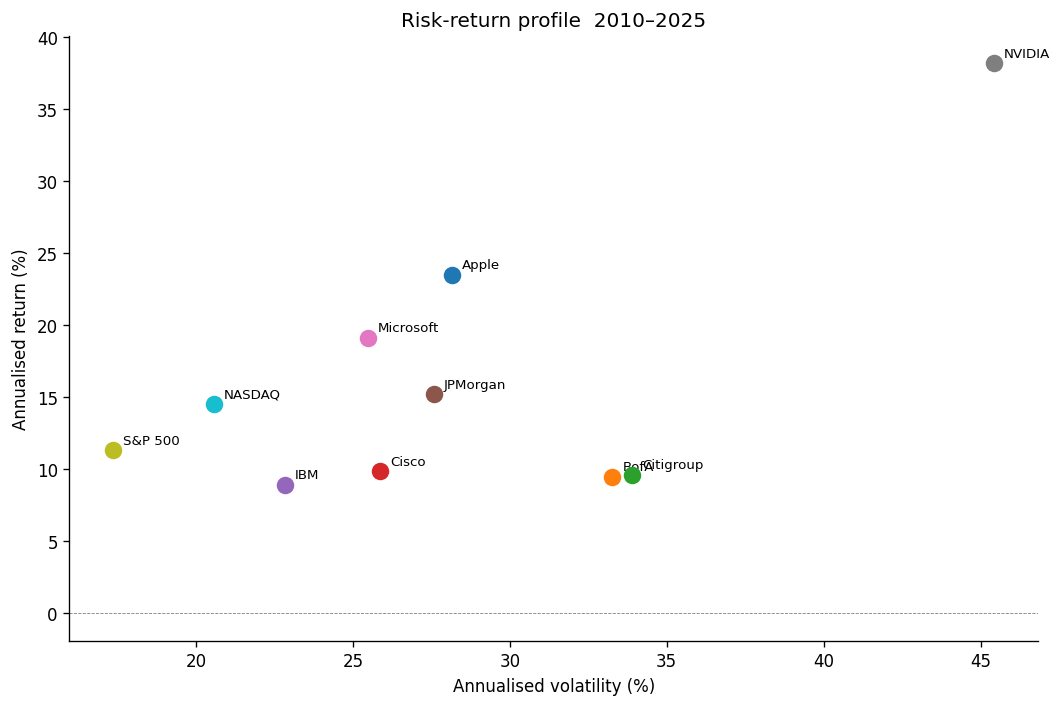

In [20]:
fig, ax = plt.subplots(figsize=(9, 6))
for i, t in enumerate(ann_ret.index):
    ax.scatter(ann_vol[t], ann_ret[t], color=PALETTE[i], s=90, zorder=3)
    ax.annotate(NAMES.get(t, t), (ann_vol[t], ann_ret[t]),
                xytext=(6, 4), textcoords='offset points', fontsize=8)
ax.axhline(0, color='grey', lw=0.5, ls='--')
ax.set_xlabel('Annualised volatility (%)')
ax.set_ylabel('Annualised return (%)')
ax.set_title('Risk-return profile  2010–2025')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'risk_return.png', bbox_inches='tight')
plt.show()


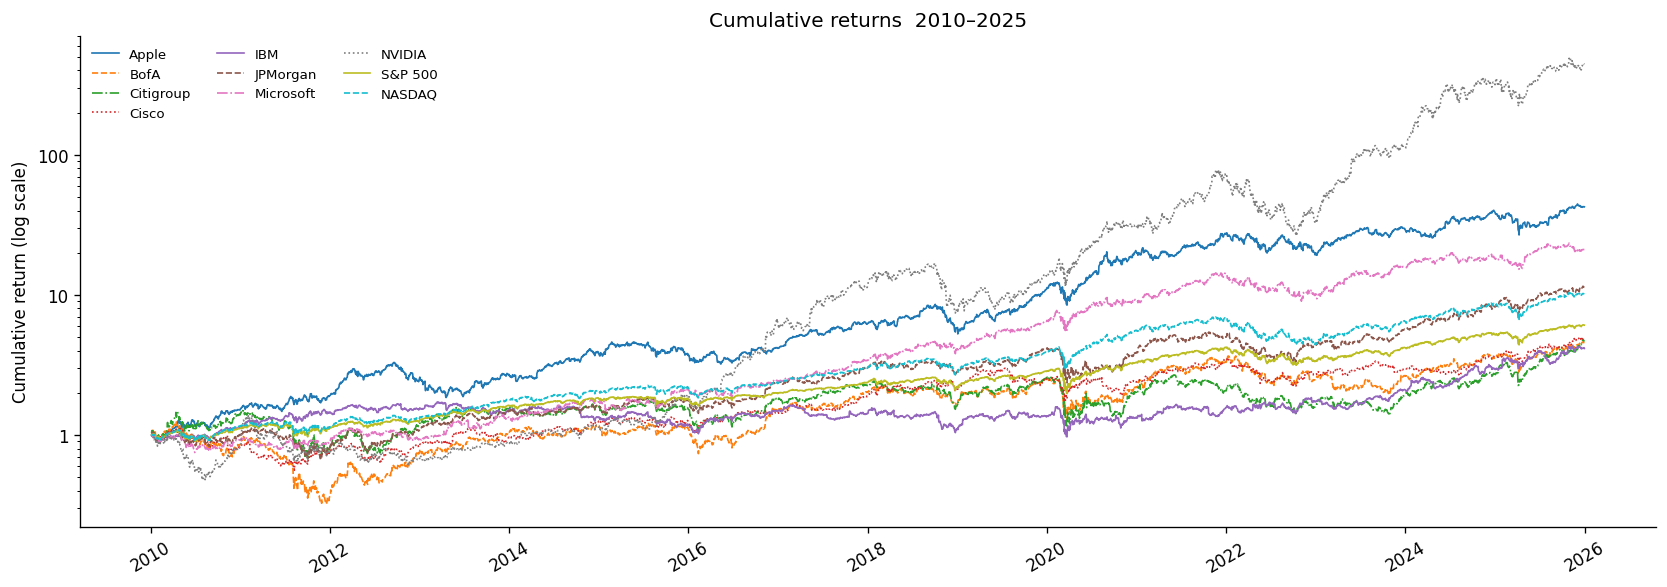

In [21]:
cum = (1 + pct).cumprod()
ls  = ['-', '--', '-.', ':'] * 3

fig, ax = plt.subplots(figsize=(14, 5))
for i, t in enumerate(cum.columns):
    ax.plot(cum[t], label=NAMES.get(t, t), color=PALETTE[i], lw=1.0, ls=ls[i % 4])
ax.set_yscale('log')
ax.set_ylabel('Cumulative return (log scale)')
ax.set_title('Cumulative returns  2010–2025')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.tick_params(axis='x', rotation=30)
ax.legend(ncol=3, fontsize=8, frameon=False)
ax.yaxis.set_major_formatter(mticker.ScalarFormatter())
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'cumulative_returns.png', bbox_inches='tight')
plt.show()


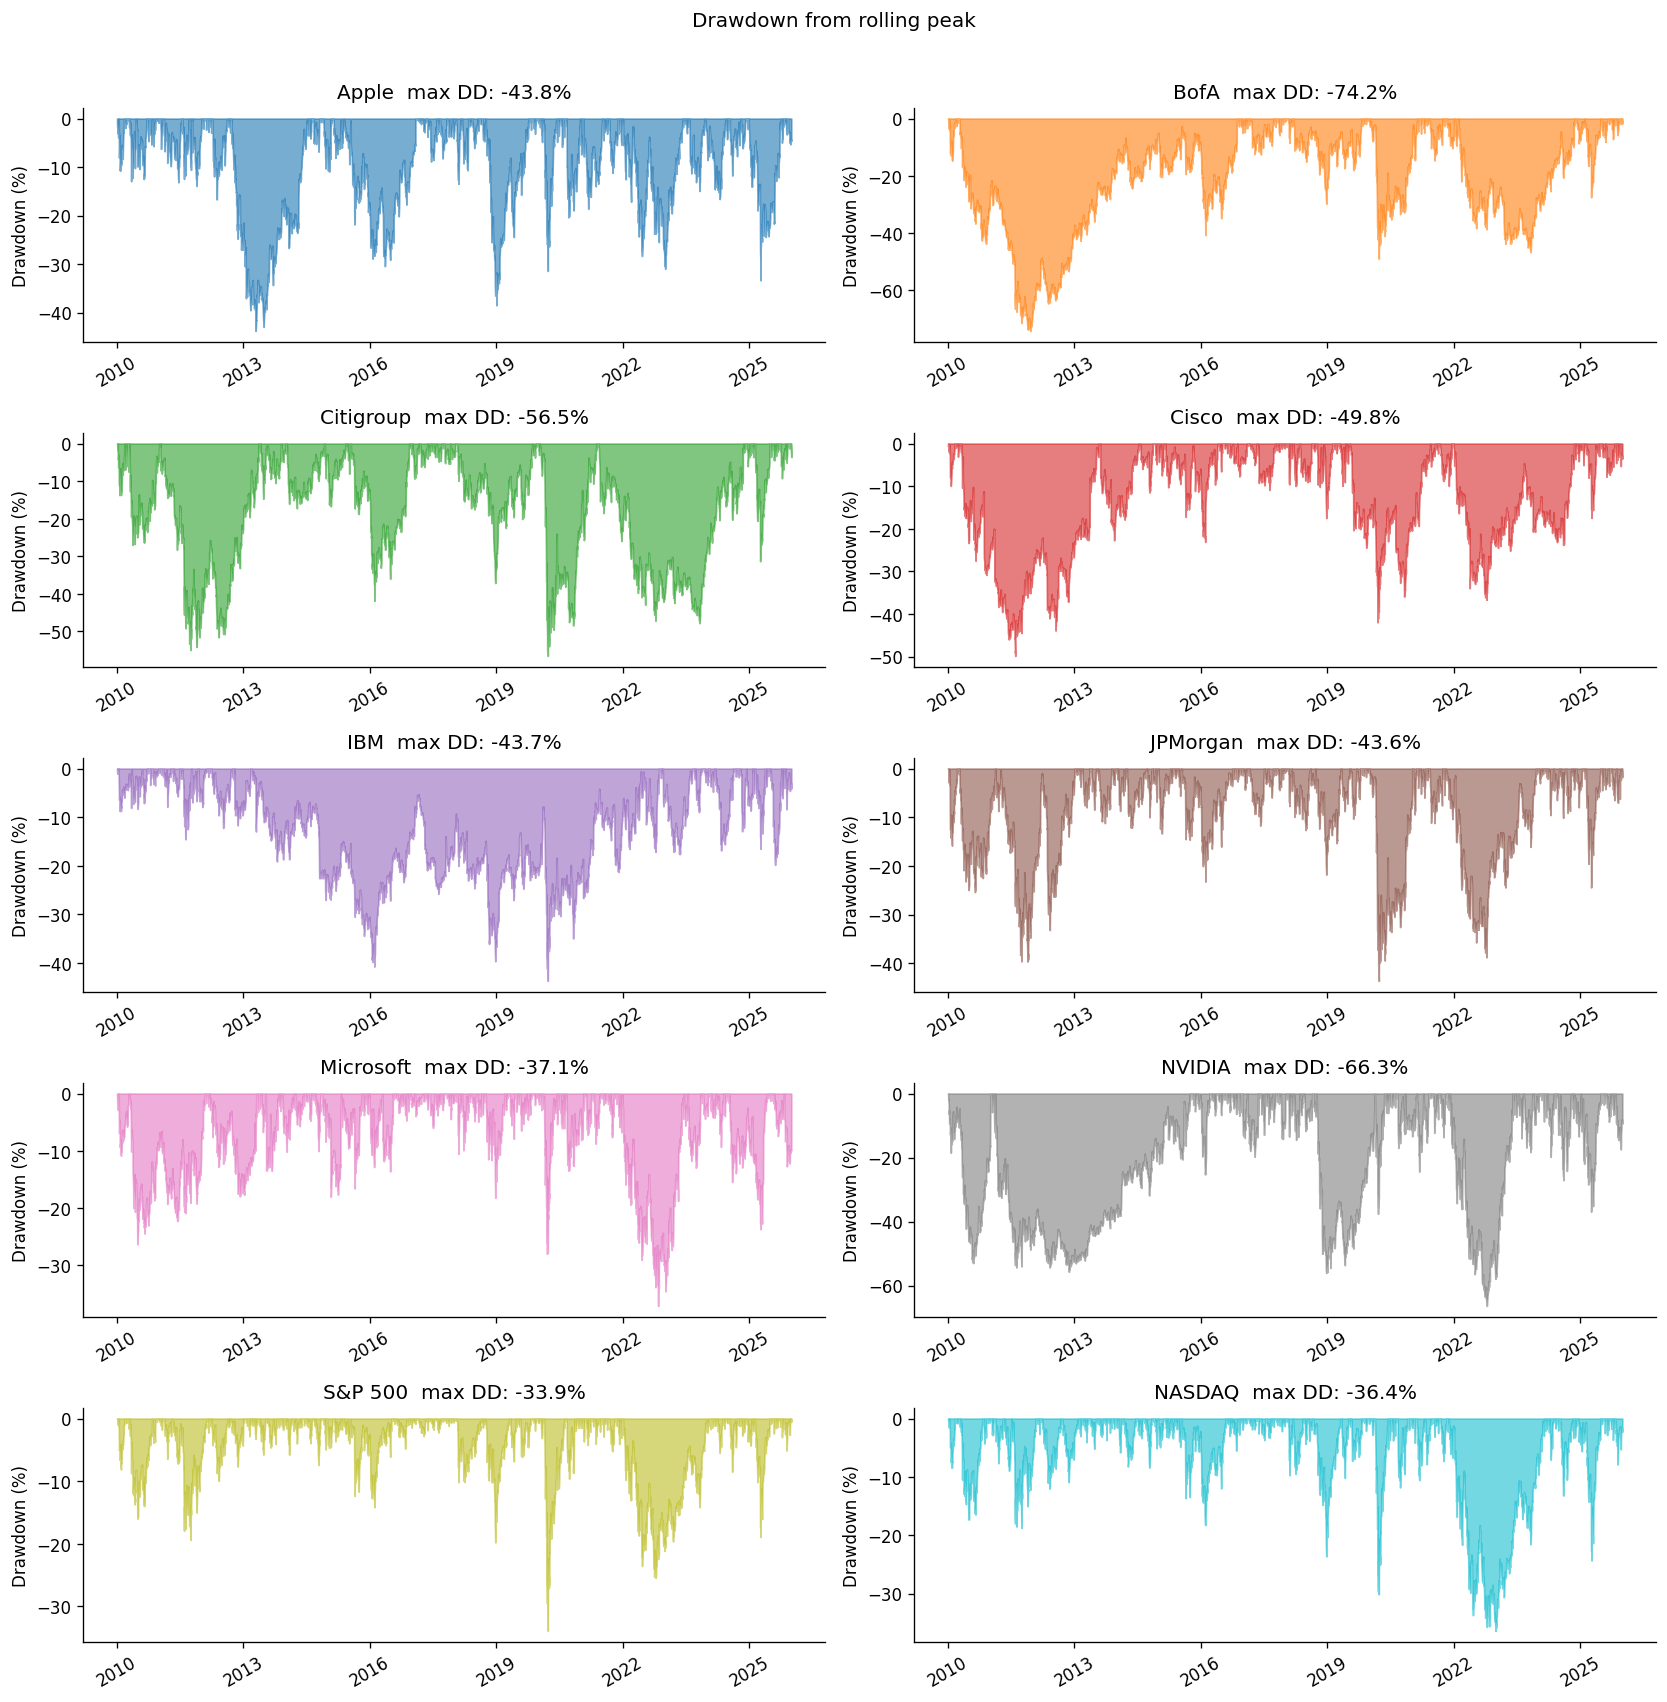

In [22]:
def max_dd(s): return ((s - s.cummax()) / s.cummax())

fig, axes = plt.subplots(N_ROWS, N_COLS, figsize=(14, N_ROWS * 2.8))
axes = axes.flatten()
for i, t in enumerate(cum.columns):
    dd = max_dd(cum[t])
    axes[i].fill_between(dd.index, dd * 100, 0, color=PALETTE[i], alpha=0.6)
    axes[i].set_title(f"{NAMES.get(t,t)}  max DD: {dd.min()*100:.1f}%")
    axes[i].set_ylabel('Drawdown (%)')
    axes[i].xaxis.set_major_locator(mdates.YearLocator(3))
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    axes[i].tick_params(axis='x', rotation=30)
for j in range(len(TICKERS), len(axes)): axes[j].set_visible(False)
plt.suptitle('Drawdown from rolling peak', y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'drawdown.png', bbox_inches='tight')
plt.show()


## 12. Feature Engineering

In [23]:
def make_features(r):
    df = pd.DataFrame(index=r.index)
    for lag in [1, 2, 3, 5, 10]:
        df[f'lag_{lag}'] = r.shift(lag)
    df['roll_mean_5']  = r.rolling(5).mean()
    df['roll_mean_21'] = r.rolling(21).mean()
    df['roll_std_5']   = r.rolling(5).std()
    df['roll_std_21']  = r.rolling(21).std()
    df['roll_skew_21'] = r.rolling(21).apply(lambda x: float(pd.Series(x).skew()), raw=True)
    df['roll_kurt_21'] = r.rolling(21).apply(lambda x: float(pd.Series(x).kurtosis()), raw=True)
    df['sq_ret']       = r ** 2
    df['abs_ret']      = r.abs()
    df['realised_var'] = df['sq_ret'].rolling(21).sum()
    df['range_5']      = r.rolling(5).max() - r.rolling(5).min()
    return df

feats = {t: make_features(ret[t]).dropna() for t in ret.columns}
msft  = feats['MSFT']
print(f"MSFT features: {msft.shape[1]} features x {msft.shape[0]} obs")
print("\nFeatures:", msft.columns.tolist())


MSFT features: 15 features x 4002 obs

Features: ['lag_1', 'lag_2', 'lag_3', 'lag_5', 'lag_10', 'roll_mean_5', 'roll_mean_21', 'roll_std_5', 'roll_std_21', 'roll_skew_21', 'roll_kurt_21', 'sq_ret', 'abs_ret', 'realised_var', 'range_5']


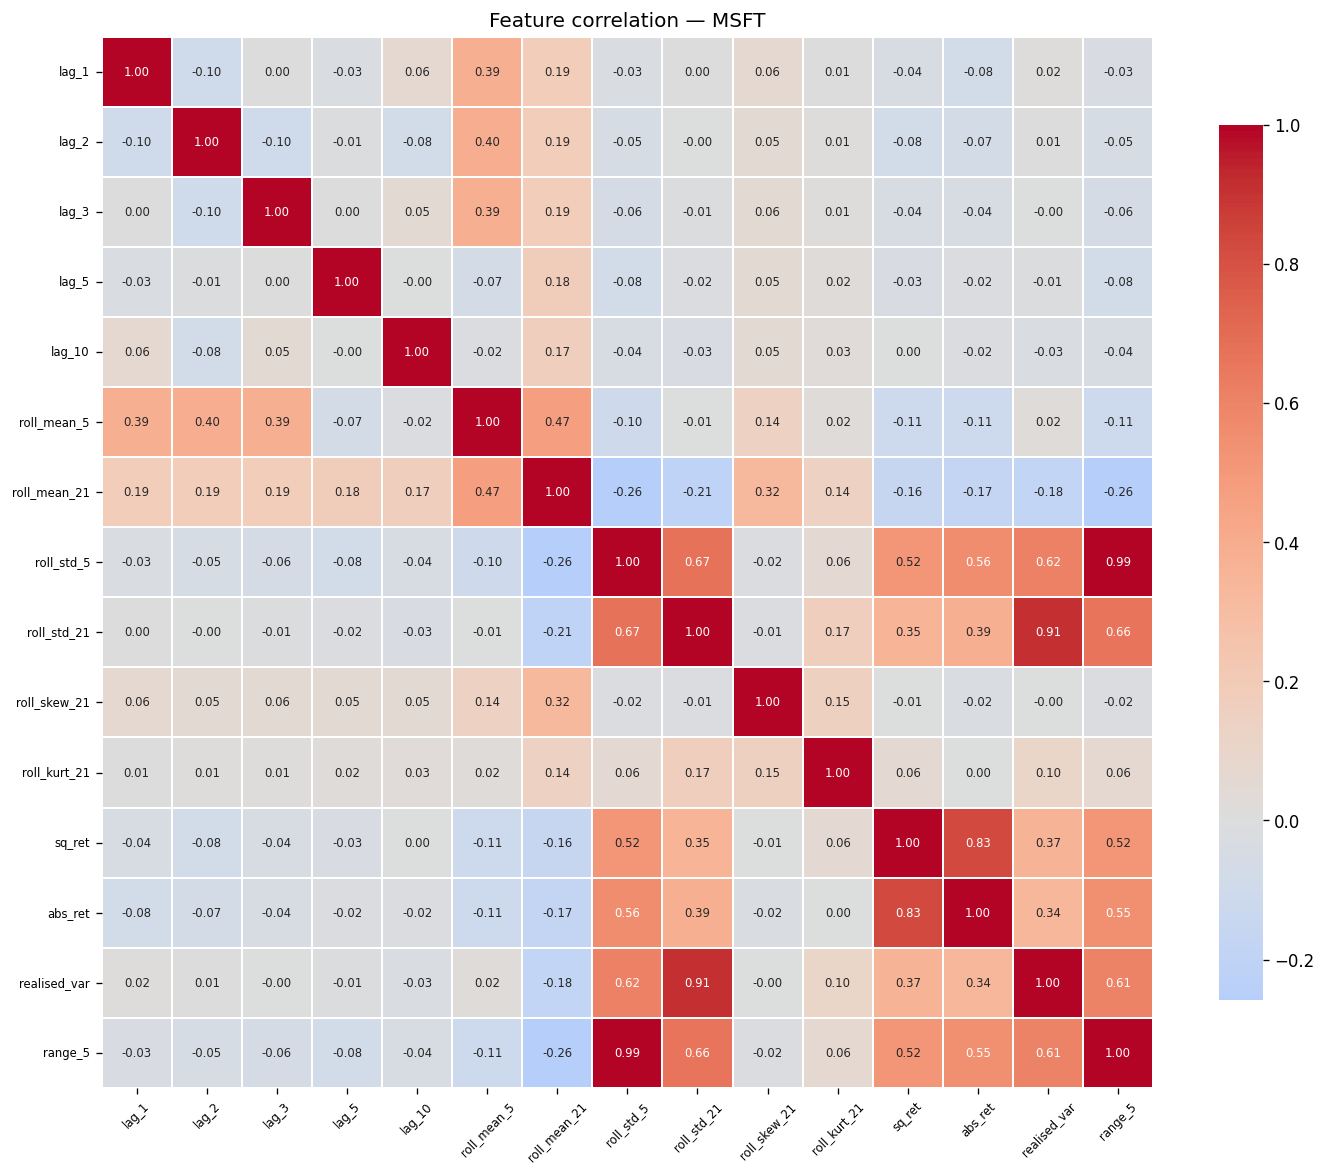

In [24]:
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(msft.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.2,
            cbar_kws={'shrink': 0.8}, annot_kws={'size': 7}, ax=ax)
ax.set_title('Feature correlation — MSFT')
ax.tick_params(axis='x', rotation=45, labelsize=7)
ax.tick_params(axis='y', rotation=0, labelsize=7)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'feature_correlation.png', bbox_inches='tight')
plt.show()


In [25]:
X = add_constant(msft)
vif = pd.DataFrame({
    'Feature': X.columns,
    'VIF':     [variance_inflation_factor(X.values, i) for i in range(X.shape[1])],
}).query("Feature != 'const'").set_index('Feature').sort_values('VIF', ascending=False).round(2)
print("VIF — MSFT feature set")
print(vif.to_string())
print("\nVIF > 10 = high multicollinearity | > 5 = moderate | <= 5 = acceptable")


VIF — MSFT feature set
                   VIF
Feature               
roll_std_5   71.410000
range_5      69.020000
roll_std_21   7.250000
realised_var  6.290000
abs_ret       3.660000
sq_ret        3.500000
roll_mean_5   2.570000
roll_mean_21  1.690000
lag_2         1.540000
lag_1         1.440000
lag_3         1.430000
roll_skew_21  1.140000
roll_kurt_21  1.130000
lag_5         1.080000
lag_10        1.060000

VIF > 10 = high multicollinearity | > 5 = moderate | <= 5 = acceptable


## 13. Preliminary VaR Estimates

In [26]:
var_rows = []
for t in ret.columns:
    r, mu, sigma = ret[t].dropna(), ret[t].mean(), ret[t].std()
    for conf in [0.95, 0.99]:
        a   = 1 - conf
        zn  = stats.norm.ppf(a)
        dof = max(4.0, 6.0 / (r.kurtosis() / 3.0 + 1.0)) if r.kurtosis() > 0 else 4.0
        zt  = stats.t.ppf(a, df=dof)
        var_rows.append({
            'Asset':       NAMES.get(t, t),
            'CL':          f'{conf:.0%}',
            'Normal (%)':  round(-(mu + sigma * zn) * 100, 4),
            'Student-t (%)':round(-(mu + sigma * zt) * 100, 4),
            'Hist Sim (%)': round(-float(np.percentile(r, a * 100)) * 100, 4),
        })

var_df = pd.DataFrame(var_rows).set_index(['Asset', 'CL'])
print("Preliminary daily VaR estimates")
print(var_df.to_string())


Preliminary daily VaR estimates
               Normal (%)  Student-t (%)  Hist Sim (%)
Asset     CL                                          
Apple     95%    2.824800       3.688800      2.707000
          99%    4.033800       6.554100      4.787100
BofA      95%    3.409600       4.430300      3.136000
          99%    4.837900       7.815200      5.799600
Citigroup 95%    3.473000       4.512600      3.167800
          99%    4.927800       7.960300      5.790600
Cisco     95%    2.640900       3.434400      2.256600
          99%    3.751300       6.065900      4.521300
IBM       95%    2.329800       3.030000      2.000100
          99%    3.309700       5.352300      4.213300
JPMorgan  95%    2.797100       3.643100      2.597900
          99%    3.981000       6.448900      4.708900
Microsoft 95%    2.564600       3.346400      2.460300
          99%    3.658600       5.939000      4.198900
NVIDIA    95%    4.555000       5.948500      4.288400
          99%    6.505000      10

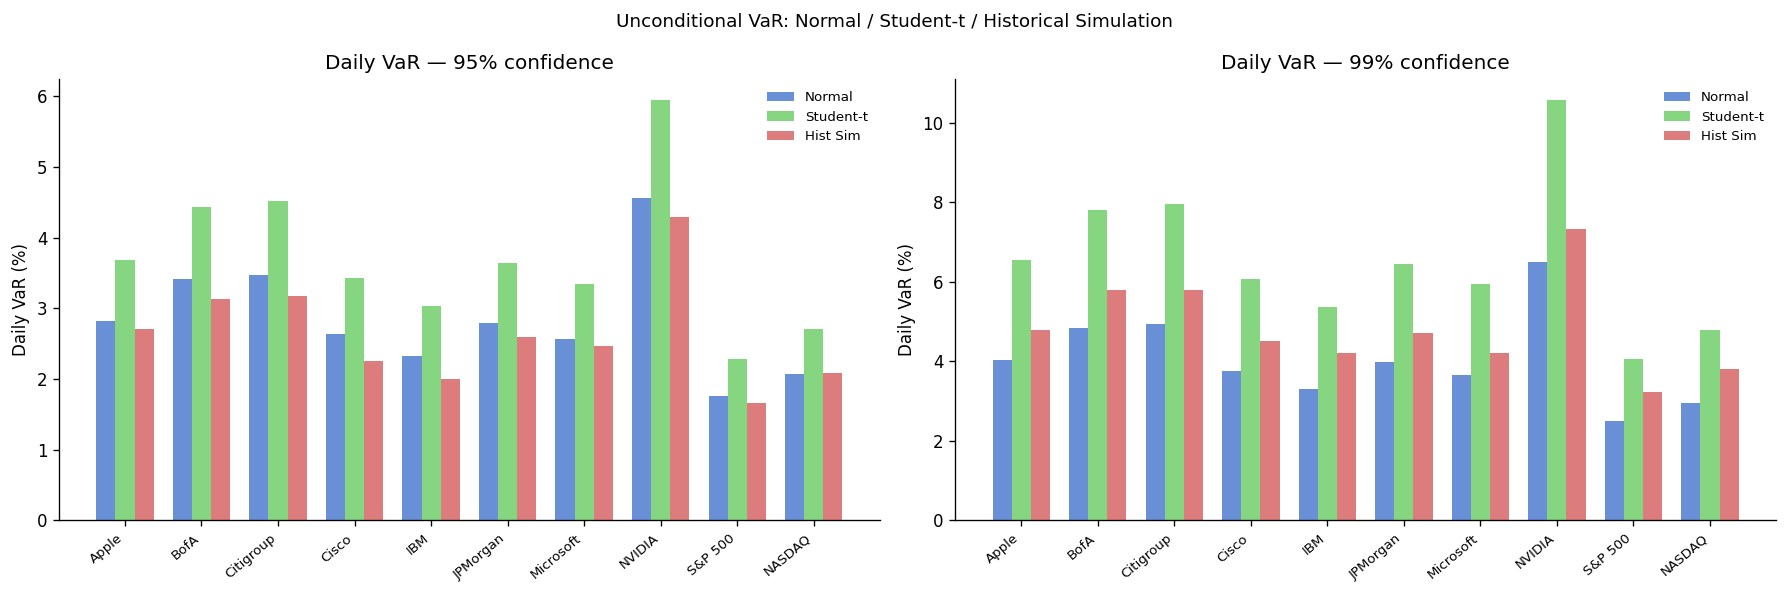

Note: unconditional estimates only. Conditional VaR via GARCH follows in notebook 03.


In [27]:
var_95 = pd.DataFrame(var_rows).query("CL == '95%'")
var_99 = pd.DataFrame(var_rows).query("CL == '99%'")
methods, colors = ['Normal (%)', 'Student-t (%)', 'Hist Sim (%)'], ['#4878CF', '#6ACC65', '#D65F5F']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
x, w = np.arange(len(var_95)), 0.25
for ax, (df_var, cl) in zip(axes, [(var_95, '95%'), (var_99, '99%')]):
    for j, (m, c) in enumerate(zip(methods, colors)):
        ax.bar(x + j * w, df_var[m], width=w, color=c, alpha=0.82,
               label=m.replace(' (%)', ''))
    ax.set_xticks(x + w)
    ax.set_xticklabels(df_var['Asset'], rotation=40, ha='right', fontsize=8)
    ax.set_ylabel('Daily VaR (%)')
    ax.set_title(f'Daily VaR — {cl} confidence')
    ax.legend(fontsize=8, frameon=False)
plt.suptitle('Unconditional VaR: Normal / Student-t / Historical Simulation', fontsize=11)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'var_preliminary.png', bbox_inches='tight')
plt.show()
print("Note: unconditional estimates only. Conditional VaR via GARCH follows in notebook 03.")
